# Ângulos

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (ponto, reta, plano e notação geométrica) e [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (semirreta, que é a base da definição de ângulo, e congruência de segmentos).

**Objetivos de aprendizagem:** ao final você será capaz de...
- Definir ângulo como a região do plano limitada por duas semirretas de mesma origem, e usar a notação e as unidades corretas (grau, minuto e segundo).
- Classificar ângulos quanto à medida (agudo, reto, obtuso, raso, de uma volta) e quanto à posição (consecutivos, adjacentes, complementares, suplementares, opostos pelo vértice).
- Comparar ângulos e verificar quando dois ângulos são congruentes.
- Encontrar a bissetriz de um ângulo e usá-la para dividir ângulos em partes congruentes.

**Tempo estimado:** 60 a 75 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0403a_angulos.ipynb)

## O que muda quando o relógio anda?

Olhe para um relógio de ponteiros à 1h, às 3h, às 5h e às 6h. Os ponteiros têm sempre o mesmo tamanho, o relógio continua no mesmo lugar da parede... e mesmo assim cada horário tem uma "cara" diferente. **O que muda?**

A resposta que vem na cabeça é: **a abertura entre os ponteiros**. À 1h eles estão quase fechados; às 6h estão abertos ao máximo, um apontando para cima e outro para baixo. A mesma ideia aparece quando você abre um leque, um guarda-chuva ou a tela de um notebook: nada cresce nem encolhe, só a **abertura** muda.

Essa abertura tem nome: **ângulo**. E ela tem uma unidade de medida que você já ouviu mil vezes, o **grau**. Uma volta completa tem **360 graus**. Mas por que 360, e não 100, que seria um número bem mais "redondo"? Guarde essa pergunta: a resposta vem de milhares de anos atrás e aparece na seção 2.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Arc, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def preparar_eixo(ax, limite: float = 3.0) -> None:
    """Deixa o eixo pronto para desenhos de geometria: estilo Nord, sem grade, sem números e com escala igual."""
    estilizar_eixo(ax)
    ax.grid(False)
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, medida a partir da horizontal no sentido anti-horário.

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar a semirreta na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def desenhar_semirreta(ax, origem, angulo_graus: float, comprimento: float = 2.6,
                       cor: str = NORD_TEXTO_SEC, largura: float = 2.5) -> np.ndarray:
    """Desenha uma semirreta saindo de `origem` na direção dada (seta numa ponta só) e devolve a ponta desenhada."""
    origem = np.array(origem, dtype=float)
    fim = origem + comprimento * direcao(angulo_graus)
    ax.annotate("", xy=fim, xytext=origem,
                arrowprops=dict(arrowstyle="-|>", color=cor, lw=largura, mutation_scale=16))
    return fim


def desenhar_reta(ax, centro, angulo_graus: float, comprimento: float = 2.6,
                  cor: str = NORD_TEXTO_SEC, largura: float = 2.5) -> None:
    """Desenha a reta que passa por `centro` na direção dada (setas nas duas pontas: a reta não acaba)."""
    centro = np.array(centro, dtype=float)
    ponta_1 = centro - comprimento * direcao(angulo_graus)
    ponta_2 = centro + comprimento * direcao(angulo_graus)
    ax.annotate("", xy=ponta_2, xytext=ponta_1,
                arrowprops=dict(arrowstyle="<|-|>", color=cor, lw=largura, mutation_scale=16))


def desenhar_angulo(ax, vertice, inicio: float, abertura: float, raio: float = 0.7,
                    cor: str = COR_PONTO, rotulo: str | None = None, arcos: int = 1,
                    marcar_reto: bool = True, raio_rotulo: float | None = None) -> None:
    """Pinta a região angular com vértice em `vertice`, que começa na direção `inicio`
    e gira `abertura` graus no sentido anti-horário, com arco(s) na borda.

    O ângulo reto ganha o quadradinho no lugar do arco, como nos livros.
    """
    if abertura <= 0:
        return
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90):
        lado = 0.55 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(plt.Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        for k in range(arcos):
            r = raio - 0.13 * k
            ax.add_patch(Arc(v, 2 * r, 2 * r, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia = raio + 0.35 if raio_rotulo is None else raio_rotulo
        posicao = v + distancia * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=12, ha="center", va="center", fontweight="bold")


def desenhar_ponto(ax, p, nome: str, cor: str = COR_AVISO, deslocamento=(0.12, 0.15)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=5)
    ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")

Vamos olhar os quatro relógios do gancho. Em cada um, o ponteiro dos minutos está no 12 e o ponteiro das horas aponta para a hora cheia. A região colorida é a abertura entre eles.

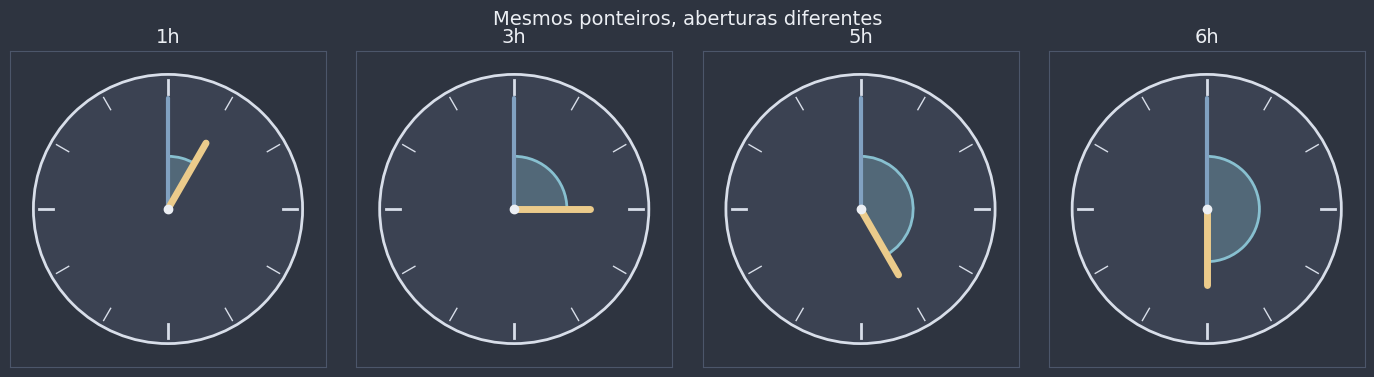

hora cheia,abertura entre os ponteiros (graus)
1,30
3,90
5,150
6,180


In [2]:
horas = [1, 3, 5, 6]

fig, eixos = plt.subplots(1, 4, figsize=(14, 3.8))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, hora in zip(eixos, horas):
    preparar_eixo(ax, 1.35)
    ax.add_patch(plt.Circle((0, 0), 1.15, facecolor=NORD_PAINEL, edgecolor=NORD_TEXTO_SEC, lw=2))
    for marca in range(12):
        d = direcao(90 - 30 * marca)
        ax.plot(*zip(0.98 * d, 1.1 * d), color=NORD_TEXTO_SEC, lw=2 if marca % 3 == 0 else 1)
    # Minutos no 12 (direção 90°) e horas girando 30° por hora no sentido horário
    direcao_horas = 90 - 30 * hora
    desenhar_angulo(ax, (0, 0), direcao_horas, 30 * hora, raio=0.45, cor=COR_PONTO, marcar_reto=False)
    ax.plot(*zip((0, 0), 0.95 * direcao(90)), color=COR_SECUNDARIA, lw=3, solid_capstyle="round")
    ax.plot(*zip((0, 0), 0.65 * direcao(direcao_horas)), color=COR_AVISO, lw=5, solid_capstyle="round")
    ax.plot(0, 0, "o", color=NORD_TEXTO, markersize=6, zorder=5)
    ax.set_title(f"{hora}h", color=NORD_TEXTO, fontsize=14)
fig.suptitle("Mesmos ponteiros, aberturas diferentes", color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

# A volta completa tem 360 graus e o mostrador tem 12 horas: cada hora "vale" 360 / 12 graus
graus_por_hora = 360 / 12
tabela_relogio = pd.DataFrame(
    {"hora cheia": horas, "abertura entre os ponteiros (graus)": [graus_por_hora * h for h in horas]}
)
display(tabela_relogio.style.format({"abertura entre os ponteiros (graus)": "{:g}"}).hide(axis="index"))

## 1. O que é um ângulo

No notebook anterior você conheceu a **semirreta**: ela começa num ponto (a **origem**) e segue ilimitada num só sentido. Agora pegue **duas** semirretas que começam **no mesmo ponto**. Elas "abrem" uma parte do plano entre elas, exatamente como os ponteiros do relógio.

📌 **Definição formal (ângulo):** **ângulo** é a região do plano limitada por duas semirretas de **mesma origem**.
- A origem comum é o **vértice** do ângulo.
- As duas semirretas são os **lados** do ângulo.

**Notação.** Com vértice O e lados $\overrightarrow{OA}$ e $\overrightarrow{OB}$, o ângulo é escrito de uma destas formas:

| Notação | Como se lê | Quando usar |
|---|---|---|
| $A\hat{O}B$ (ou $\angle AOB$) | "ângulo A O B" | sempre funciona; o **vértice fica no meio** |
| $\hat{O}$ | "ângulo O" | quando só existe um ângulo com vértice O no desenho |
| $\alpha$, $\beta$, $\gamma$... | "alfa", "beta", "gama" | letra grega escrita dentro da abertura, perto do vértice |

Repare: $A\hat{O}B$ e $B\hat{O}A$ são **o mesmo ângulo** (os mesmos lados), assim como $\overline{AB}$ e $\overline{BA}$ eram o mesmo segmento. O que não pode é tirar o vértice do meio: $O\hat{A}B$ seria um ângulo com vértice em A, que é outra coisa.

💡 **Dica — ângulo como região ou como "contorno"?** Alguns livros chamam de ângulo só a **reunião das duas semirretas** (o "contorno", como em [`0501a_arcos_e_angulos.ipynb`](../05_trigonometria/0501a_arcos_e_angulos.ipynb)) e chamam a parte do plano entre elas de **região angular** ou **interior do ângulo**. As duas visões convivem sem briga: o que vamos medir, nos dois casos, é a **abertura** entre os lados.

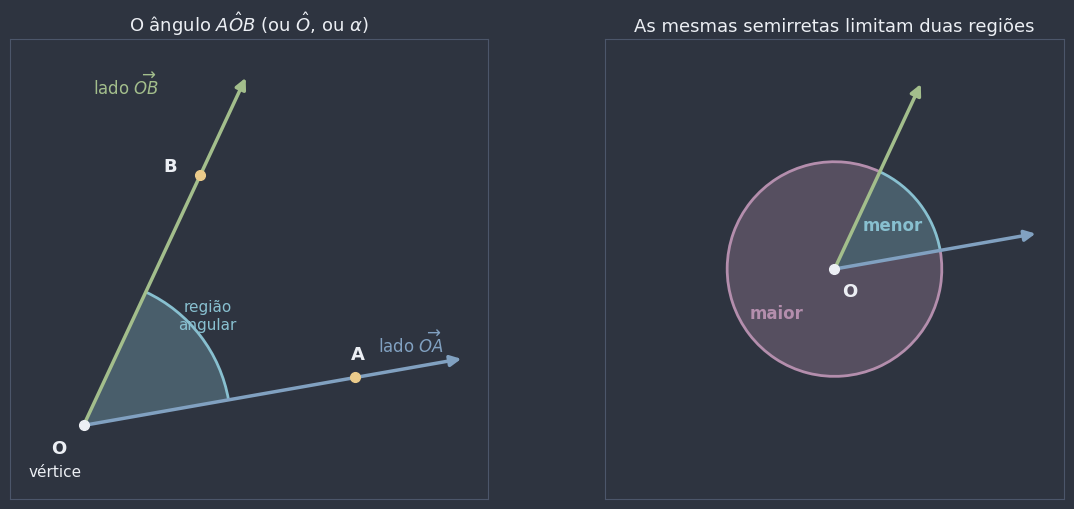

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2))
fig.patch.set_facecolor(NORD_FUNDO)

# Esquerda: as partes de um ângulo
preparar_eixo(ax1, 3.0)
ax1.set_xlim(-1.8, 3.4)
ax1.set_ylim(-1.8, 3.2)
vertice = (-1.0, -1.0)
dir_a, dir_b = 10, 65
desenhar_angulo(ax1, vertice, dir_a, dir_b - dir_a, raio=1.6, cor=COR_PONTO)
fim_a = desenhar_semirreta(ax1, vertice, dir_a, comprimento=4.2, cor=COR_SECUNDARIA)
fim_b = desenhar_semirreta(ax1, vertice, dir_b, comprimento=4.2, cor=COR_DESTAQUE)
ponto_a = np.array(vertice) + 3.0 * direcao(dir_a)
ponto_b = np.array(vertice) + 3.0 * direcao(dir_b)
desenhar_ponto(ax1, vertice, "O", cor=NORD_TEXTO, deslocamento=(-0.35, -0.3))
desenhar_ponto(ax1, ponto_a, "A", deslocamento=(-0.05, 0.2))
desenhar_ponto(ax1, ponto_b, "B", deslocamento=(-0.4, 0.05))
ax1.text(-1.6, -1.55, "vértice", color=NORD_TEXTO, fontsize=11)
ax1.text(2.2, -0.2, r"lado $\overrightarrow{OA}$", color=COR_SECUNDARIA, fontsize=12)
ax1.text(-0.9, 2.6, r"lado $\overrightarrow{OB}$", color=COR_DESTAQUE, fontsize=12)
ax1.text(0.35, 0.05, "região\nangular", color=COR_PONTO, fontsize=11, ha="center")
ax1.set_title(r"O ângulo $A\hat{O}B$ (ou $\hat{O}$, ou $\alpha$)", color=NORD_TEXTO, fontsize=13)

# Direita: duas semirretas separam o plano em DUAS regiões
preparar_eixo(ax2, 3.0)
o = (0, 0)
desenhar_angulo(ax2, o, dir_a, dir_b - dir_a, raio=1.4, cor=COR_PONTO, rotulo="menor", raio_rotulo=0.95)
desenhar_angulo(ax2, o, dir_b, 360 - (dir_b - dir_a), raio=1.4, cor=COR_EXTRA, rotulo="maior", raio_rotulo=0.95)
desenhar_semirreta(ax2, o, dir_a, comprimento=2.7, cor=COR_SECUNDARIA)
desenhar_semirreta(ax2, o, dir_b, comprimento=2.7, cor=COR_DESTAQUE)
desenhar_ponto(ax2, o, "O", cor=NORD_TEXTO, deslocamento=(0.1, -0.35))
ax2.set_title("As mesmas semirretas limitam duas regiões", color=NORD_TEXTO, fontsize=13)

plt.tight_layout()
plt.show()

Repare no desenho da direita: duas semirretas de mesma origem dividem o plano em **duas** regiões, uma "menor" e uma "maior". Quando se fala em "o ângulo $A\hat{O}B$" sem dizer mais nada, a combinação é sempre usar a região **menor**. A região maior aparece quando for preciso, e ela vai ganhar nome na próxima seção.

**Na linguagem dos números.** Olhando a partir do vértice O, cada ponto do plano está numa **direção**, que dá para medir em graus a partir da horizontal (o Python calcula isso com `math.atan2`). Um ponto P está **no interior** do ângulo quando a direção de P fica **entre** as direções dos dois lados. Vamos testar alguns pontos com o lado $\overrightarrow{OA}$ na direção 15° e o lado $\overrightarrow{OB}$ na direção 75°:

ponto,coordenadas,direção vista de O,no interior de AÔB?
P1,"(2, 1)",26.6°,✅
P2,"(0.5, 2.2)",77.2°,❌
P3,"(-1.5, 1)",146.3°,❌
P4,"(2.5, 0.2)",4.6°,❌
P5,"(1.5, 1.5)",45.0°,✅
P6,"(1.2, -1.2)",315.0°,❌


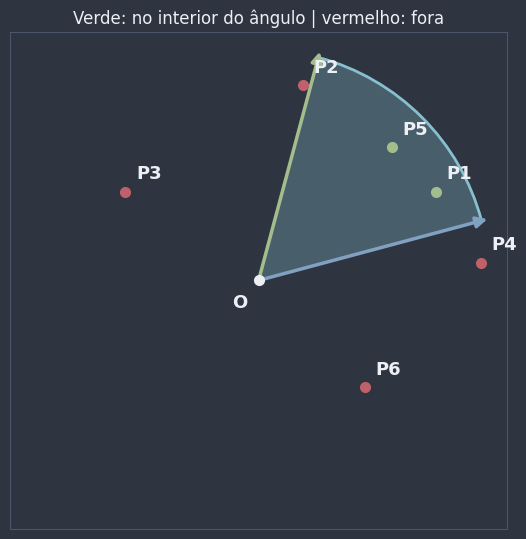

In [4]:
dir_oa, dir_ob = 15, 75


def direcao_do_ponto(p: tuple[float, float]) -> float:
    """Direção, em graus de 0 a 360, em que o ponto p está quando visto do vértice (0, 0)."""
    return math.degrees(math.atan2(p[1], p[0])) % 360


def marca(condicao: bool) -> str:
    """Troca True/False por um símbolo mais fácil de ler na tabela."""
    return "✅" if condicao else "❌"


pontos_testados = {"P1": (2, 1), "P2": (0.5, 2.2), "P3": (-1.5, 1), "P4": (2.5, 0.2), "P5": (1.5, 1.5), "P6": (1.2, -1.2)}
linhas = []
for nome, p in pontos_testados.items():
    d = direcao_do_ponto(p)
    linhas.append({"ponto": nome, "coordenadas": p, "direção vista de O": d, "no interior de AÔB?": marca(dir_oa < d < dir_ob)})
display(pd.DataFrame(linhas).style.format({"direção vista de O": "{:.1f}°"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, 2.8)
desenhar_angulo(ax, (0, 0), dir_oa, dir_ob - dir_oa, raio=2.6, cor=COR_PONTO)
desenhar_semirreta(ax, (0, 0), dir_oa, comprimento=2.7, cor=COR_SECUNDARIA)
desenhar_semirreta(ax, (0, 0), dir_ob, comprimento=2.7, cor=COR_DESTAQUE)
for nome, p in pontos_testados.items():
    dentro = dir_oa < direcao_do_ponto(p) < dir_ob
    desenhar_ponto(ax, p, nome, cor=COR_DESTAQUE if dentro else COR_ALERTA)
desenhar_ponto(ax, (0, 0), "O", cor=NORD_TEXTO, deslocamento=(-0.3, -0.3))
ax.set_title("Verde: no interior do ângulo | vermelho: fora", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** o lado $\overrightarrow{OA}$ fica parado e o lado $\overrightarrow{OB}$ gira a partir dele, controlado pelo slider `abertura`. O slider `girar tudo` gira a figura inteira. Observe duas coisas: (1) a região angular cresce e diminui só com a `abertura`; (2) girar a figura inteira **não muda** a abertura. Leve a `abertura` até o fim e veja o que acontece quando $\overrightarrow{OB}$ dá a volta completa.

In [5]:
def explorar_abertura(abertura: float, giro: float) -> None:
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, 3.0)
    o = (0, 0)
    desenhar_angulo(ax, o, giro, abertura, raio=1.1, cor=COR_PONTO, marcar_reto=False)
    desenhar_semirreta(ax, o, giro, cor=COR_SECUNDARIA)
    desenhar_semirreta(ax, o, giro + abertura, cor=COR_DESTAQUE, largura=2)
    desenhar_ponto(ax, 2.0 * direcao(giro), "A")
    desenhar_ponto(ax, 2.0 * direcao(giro + abertura), "B")
    desenhar_ponto(ax, o, "O", cor=NORD_TEXTO, deslocamento=(-0.35, -0.35))
    if abertura == 0:
        titulo = "Lados sobrepostos: nenhuma abertura"
    elif abertura == 360:
        titulo = "OB deu a volta completa e voltou a coincidir com OA"
    else:
        titulo = "OB girou a partir de OA: essa abertura é o ângulo"
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=11)
    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_abertura,
    abertura=widgets.IntSlider(value=50, min=0, max=360, step=5, description="abertura:"),
    giro=widgets.IntSlider(value=0, min=0, max=360, step=15, description="girar tudo:"),
);

interactive(children=(IntSlider(value=50, description='abertura:', max=360, step=5), IntSlider(value=0, descri…

⚠️ **Erro comum:** achar que o ângulo fica "maior" quando os lados são desenhados mais compridos. Os lados são **semirretas**, ilimitadas: o comprimento do traço no papel é só um jeito de desenhar. O que define o ângulo é a **abertura**, e ela não muda se você prolongar os lados.

📖 **Leitura complementar:** [Ângulo](https://pt.wikipedia.org/wiki/%C3%82ngulo)

**Pergunta de checagem:** duas semirretas com origens **diferentes** formam um ângulo? Releia a definição com atenção antes de responder.

**Pergunta de checagem:** num desenho aparecem três semirretas com a mesma origem O, passando por A, B e C. Por que escrever só "$\hat{O}$" seria ambíguo nesse caso? Quantos ângulos (usando sempre a região menor) diferentes dá para nomear com essas três semirretas?

## 2. Medida e classificação de ângulos

Para medir segmentos, a gente escolheu uma unidade (o centímetro) e contou quantas vezes ela cabe no segmento. Com ângulos é igual: divide-se a **volta completa** em 360 partes iguais, e cada parte é **1 grau** (1°).

📌 **Grau e suas subdivisões:**

$$1\ \text{volta} = 360^\circ \qquad 1^\circ = 60' \ (\text{minutos}) \qquad 1' = 60'' \ (\text{segundos})$$

Portanto $1^\circ = 60 \cdot 60 = 3600''$. Um ângulo como $32^\circ\, 15'\, 36''$ (lê-se "32 graus, 15 minutos e 36 segundos") está na forma **sexagesimal** (de base 60). Para passar para graus com vírgula: $32 + \frac{15}{60} + \frac{36}{3600} = 32{,}26^\circ$.

💡 **Dica:** esses minutos e segundos **não** são de tempo, são pedacinhos de grau. Só o nome e a base 60 são os mesmos do relógio (e não por acaso, como a curiosidade abaixo conta).

**Classificação pela medida:**

| Nome | Medida | Como é |
|---|---|---|
| **ângulo nulo** | $0^\circ$ | os dois lados coincidem, sem abertura |
| **ângulo agudo** | entre $0^\circ$ e $90^\circ$ | "fechado", mais estreito que um canto de folha |
| **ângulo reto** | exatamente $90^\circ$ | o canto de uma folha; marcado com um **quadradinho** |
| **ângulo obtuso** | entre $90^\circ$ e $180^\circ$ | "aberto", mais largo que o reto |
| **ângulo raso** | exatamente $180^\circ$ | os lados são semirretas **opostas** e formam uma reta |
| **ângulo de uma volta** (ou **giro**) | exatamente $360^\circ$ | o lado deu a volta inteira e coincidiu com o outro |

Os ângulos entre $180^\circ$ e $360^\circ$ (a "região maior" da seção 1) são chamados **côncavos** (ou reflexos). Eles quase não aparecem neste notebook, mas o código abaixo sabe reconhecê-los.

🕵️ **Curiosidade histórica — por que 360?** Há milhares de anos, povos da Mesopotâmia, como os **babilônios**, observavam o céu com muito cuidado e contavam os dias do ano. Uma explicação tradicional diz que eles viam o Sol "andar" um pouquinho por dia em relação às estrelas e dar uma volta completa em **cerca de 360 dias**: cada "passo" diário do Sol virou uma unidade de medida da volta, o grau. Além disso, os babilônios contavam em **base 60** (em vez da nossa base 10), e é daí que vêm os 60 minutos e os 60 segundos, tanto do grau quanto da hora. E há um bônus prático: 360 é um número **cheio de divisores**, o que facilita dividir a volta em metades, terços, quartos, quintos, sextos, oitavos, nonos, décimos, doze partes...

In [6]:
def divisores(n: int) -> list[int]:
    """Lista todos os divisores positivos de n."""
    return [d for d in range(1, n + 1) if n % d == 0]


for total in (100, 360):
    lista = divisores(total)
    print(f"{total} tem {len(lista)} divisores: {lista}")

print("\nDividindo a volta em partes iguais (graus inteiros?):")
for partes in (3, 6, 8, 9, 12, 24):
    print(f"  {partes:>2} partes: 360/{partes} = {360 / partes:g}°   |   se a volta fosse 100: 100/{partes} = {100 / partes:.4g}")

100 tem 9 divisores: [1, 2, 4, 5, 10, 20, 25, 50, 100]
360 tem 24 divisores: [1, 2, 3, 4, 5, 6, 8, 9, 10, 12, 15, 18, 20, 24, 30, 36, 40, 45, 60, 72, 90, 120, 180, 360]

Dividindo a volta em partes iguais (graus inteiros?):
   3 partes: 360/3 = 120°   |   se a volta fosse 100: 100/3 = 33.33
   6 partes: 360/6 = 60°   |   se a volta fosse 100: 100/6 = 16.67
   8 partes: 360/8 = 45°   |   se a volta fosse 100: 100/8 = 12.5
   9 partes: 360/9 = 40°   |   se a volta fosse 100: 100/9 = 11.11
  12 partes: 360/12 = 30°   |   se a volta fosse 100: 100/12 = 8.333
  24 partes: 360/24 = 15°   |   se a volta fosse 100: 100/24 = 4.167


Agora as conversões entre a forma com vírgula (graus decimais) e a forma sexagesimal (graus, minutos e segundos). A ideia é sempre a mesma: 1° vale 60′ e 1′ vale 60″, então 1° vale 3600″.

In [7]:
def para_graus_decimais(graus: int, minutos: int = 0, segundos: float = 0) -> float:
    """Converte um ângulo em graus, minutos e segundos para graus com vírgula."""
    return graus + minutos / 60 + segundos / 3600


def para_gms(medida: float) -> tuple[int, int, int]:
    """Converte graus com vírgula para (graus, minutos, segundos), com segundos arredondados."""
    total_segundos = round(medida * 3600)
    graus, resto = divmod(total_segundos, 3600)
    minutos, segundos = divmod(resto, 60)
    return graus, minutos, segundos


def formatar_gms(medida: float) -> str:
    """Escreve a medida no formato 32° 15′ 36″."""
    g, m, s = para_gms(medida)
    return f"{g}° {m}′ {s}″"


print(f"32° 15′ 36″ = {para_graus_decimais(32, 15, 36):g}°")
print(f"90,5° = {formatar_gms(90.5)}")
print()

medidas_exemplo = [30.5, 45.25, 32.26, 12.3456, 0.1, 179.99]
tabela_gms = pd.DataFrame({
    "graus decimais": medidas_exemplo,
    "graus, minutos e segundos": [formatar_gms(m) for m in medidas_exemplo],
    "em segundos (″)": [round(m * 3600) for m in medidas_exemplo],
})
display(tabela_gms.style.format({"graus decimais": "{:g}"}).hide(axis="index"))

32° 15′ 36″ = 32.26°
90,5° = 90° 30′ 0″



graus decimais,"graus, minutos e segundos",em segundos (″)
30.5,30° 30′ 0″,109800
45.25,45° 15′ 0″,162900
32.26,32° 15′ 36″,116136
12.3456,12° 20′ 44″,44444
0.1,0° 6′ 0″,360
179.99,179° 59′ 24″,647964


A classificação pela medida vira uma função com uma sequência de `if`. Um detalhe importante: como o computador faz contas com números decimais aproximados, usamos `math.isclose` para testar se uma medida é **exatamente** 90°, 180° ou 360°, em vez de `==`.

medida (graus),sexagesimal,classificação
0,0° 0′ 0″,nulo
35,35° 0′ 0″,agudo
89.99,89° 59′ 24″,agudo
90,90° 0′ 0″,reto
90.5,90° 30′ 0″,obtuso
135,135° 0′ 0″,obtuso
180,180° 0′ 0″,raso
250,250° 0′ 0″,côncavo
360,360° 0′ 0″,giro
45.5,45° 30′ 0″,agudo


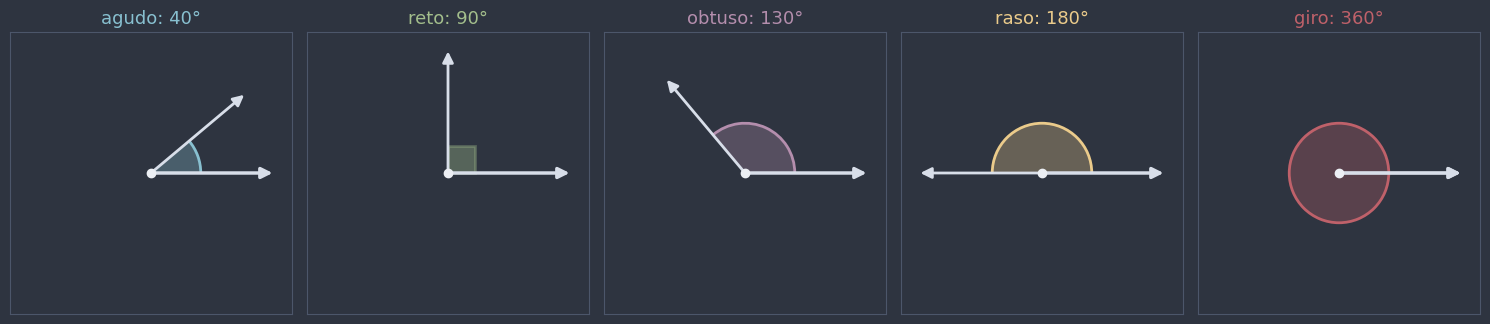

In [8]:
def classificar_angulo(medida: float) -> str:
    """Classifica um ângulo pela medida, em graus (de 0 a 360)."""
    if medida < 0 or medida > 360:
        raise ValueError("Use medidas entre 0° e 360°.")
    if math.isclose(medida, 0):
        return "nulo"
    if math.isclose(medida, 90):
        return "reto"
    if math.isclose(medida, 180):
        return "raso"
    if math.isclose(medida, 360):
        return "giro"
    if medida < 90:
        return "agudo"
    if medida < 180:
        return "obtuso"
    return "côncavo"


medidas_testadas = [0, 35, 89.99, 90, 90.5, 135, 180, 250, 360, para_graus_decimais(45, 30)]
tabela_classes = pd.DataFrame({
    "medida (graus)": medidas_testadas,
    "sexagesimal": [formatar_gms(m) for m in medidas_testadas],
    "classificação": [classificar_angulo(m) for m in medidas_testadas],
})
display(tabela_classes.style.format({"medida (graus)": "{:g}"}).hide(axis="index"))

# Galeria com um representante de cada classe
CORES_CLASSE = {"nulo": NORD_TEXTO_SEC, "agudo": COR_PONTO, "reto": COR_DESTAQUE, "obtuso": COR_EXTRA,
                "raso": COR_AVISO, "côncavo": COR_SECUNDARIA, "giro": COR_ALERTA}
exemplos = [40, 90, 130, 180, 360]
fig, eixos = plt.subplots(1, 5, figsize=(15, 3.6))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, medida in zip(eixos, exemplos):
    preparar_eixo(ax, 1.7)
    classe = classificar_angulo(medida)
    cor = CORES_CLASSE[classe]
    desenhar_angulo(ax, (0, 0), 0, medida, raio=0.6, cor=cor)
    desenhar_semirreta(ax, (0, 0), 0, comprimento=1.5)
    desenhar_semirreta(ax, (0, 0), medida, comprimento=1.5, largura=2)
    ax.plot(0, 0, "o", color=NORD_TEXTO, markersize=6, zorder=5)
    ax.set_title(f"{classe}: {medida}°", color=cor, fontsize=13)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática — o transferidor:** o instrumento para medir ângulos é o **transferidor**, uma régua em forma de meia-volta, graduada de 0° a 180°. Para medir: (1) coloque o **centro** do transferidor sobre o **vértice**; (2) alinhe a marca do **0°** com um dos lados; (3) leia o número por onde passa o **outro lado**.

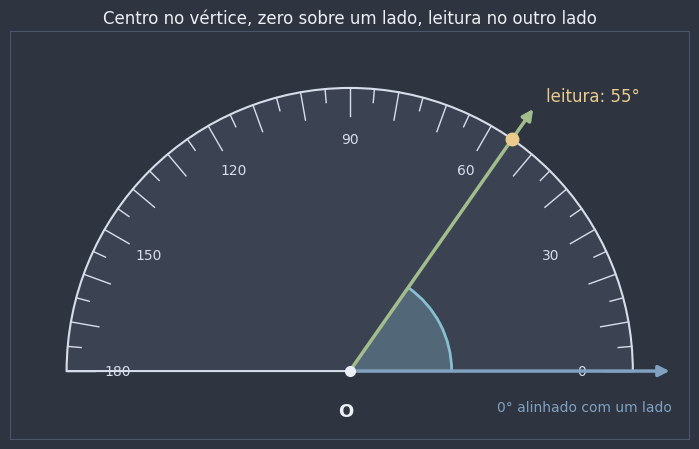

In [9]:
medida_lida = 55

fig, ax = plt.subplots(figsize=(8, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, 3.0)
ax.set_ylim(-0.6, 3.0)

# O transferidor: meia-volta graduada
ax.add_patch(Wedge((0, 0), 2.5, 0, 180, facecolor=NORD_PAINEL, edgecolor=NORD_TEXTO_SEC, lw=1.5))
for grau in range(0, 181, 5):
    d = direcao(grau)
    tamanho = 0.25 if grau % 10 == 0 else 0.12
    ax.plot(*zip((2.5 - tamanho) * d, 2.5 * d), color=NORD_TEXTO_SEC, lw=1)
    if grau % 30 == 0:
        ax.text(*(2.05 * d), f"{grau}", color=NORD_TEXTO_SEC, fontsize=10, ha="center", va="center")

# O ângulo sendo medido
desenhar_angulo(ax, (0, 0), 0, medida_lida, raio=0.9, cor=COR_PONTO)
desenhar_semirreta(ax, (0, 0), 0, comprimento=2.85, cor=COR_SECUNDARIA)
desenhar_semirreta(ax, (0, 0), medida_lida, comprimento=2.85, cor=COR_DESTAQUE)
ax.plot(*(2.5 * direcao(medida_lida)), "o", color=COR_AVISO, markersize=9, zorder=6)
ax.text(*(2.85 * direcao(medida_lida) + np.array([0.1, 0.05])), f"leitura: {medida_lida}°", color=COR_AVISO, fontsize=12)
desenhar_ponto(ax, (0, 0), "O", cor=NORD_TEXTO, deslocamento=(-0.1, -0.4))
ax.text(1.3, -0.35, "0° alinhado com um lado", color=COR_SECUNDARIA, fontsize=10)
ax.set_title("Centro no vértice, zero sobre um lado, leitura no outro lado", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática — o ângulo de um chute:** num chute ou num arremesso, a bola sai com uma certa velocidade e um certo **ângulo de lançamento** em relação ao chão. A velocidade sendo a mesma, só mudar o ângulo já muda completamente a trajetória. A Física tem uma fórmula para a trajetória (sem resistência do ar) que usa funções da Trigonometria, que você ainda vai estudar; por enquanto, use-a como uma "caixa-preta" e repare no efeito do ângulo.

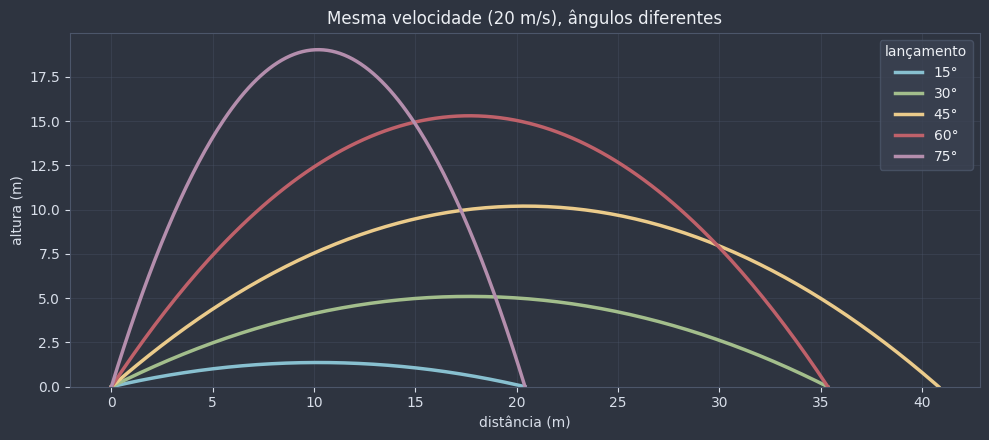

ângulo,alcance (m),altura máxima (m)
15° (agudo),20.4,1.4
30° (agudo),35.3,5.1
45° (agudo),40.8,10.2
60° (agudo),35.3,15.3
75° (agudo),20.4,19.0


In [10]:
velocidade = 20  # m/s, a mesma em todos os chutes
gravidade = 9.8  # m/s²
angulos_de_lancamento = [15, 30, 45, 60, 75]
cores = [COR_PONTO, COR_DESTAQUE, COR_AVISO, COR_ALERTA, COR_EXTRA]

fig, ax = plt.subplots(figsize=(10, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
linhas = []
for angulo, cor in zip(angulos_de_lancamento, cores):
    theta = math.radians(angulo)
    alcance = velocidade**2 * math.sin(2 * theta) / gravidade
    altura_maxima = (velocidade * math.sin(theta)) ** 2 / (2 * gravidade)
    x = np.linspace(0, alcance, 200)
    y = x * math.tan(theta) - gravidade * x**2 / (2 * velocidade**2 * math.cos(theta) ** 2)
    ax.plot(x, y, color=cor, lw=2.5, label=f"{angulo}°")
    linhas.append({"ângulo": f"{angulo}° ({classificar_angulo(angulo)})", "alcance (m)": alcance, "altura máxima (m)": altura_maxima})
ax.set_xlabel("distância (m)", color=NORD_TEXTO_SEC)
ax.set_ylabel("altura (m)", color=NORD_TEXTO_SEC)
ax.set_ylim(bottom=0)
ax.legend(facecolor=NORD_PAINEL, edgecolor=NORD_LINHA, labelcolor=NORD_TEXTO, title="lançamento", title_fontsize=10)
ax.get_legend().get_title().set_color(NORD_TEXTO)
ax.set_title("Mesma velocidade (20 m/s), ângulos diferentes", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

display(pd.DataFrame(linhas).style.format({"alcance (m)": "{:.1f}", "altura máxima (m)": "{:.1f}"}).hide(axis="index"))

Duas coisas chamam a atenção na tabela: o maior alcance acontece com **45°**, e os pares **15° e 75°** e **30° e 60°** chegam **no mesmo lugar** (um por baixo, outro por cima). Repare que em cada par a soma dá 90°. Esses pares têm nome, e você vai conhecê-los na seção 4.

🕹️ **Widget interativo:** o mesmo ângulo do widget anterior, agora com a **medida** em graus decimais e em graus e minutos, e a **classificação** mudando de cor conforme o ângulo. O slider anda de meio em meio grau: passe devagar por 90° e por 180° e veja como a classificação muda num único passo.

In [11]:
def medir_e_classificar(medida: float) -> None:
    classe = classificar_angulo(medida)
    cor = CORES_CLASSE[classe]
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, 3.0)
    o = (0, 0)
    desenhar_angulo(ax, o, 0, medida, raio=1.1, cor=cor)
    desenhar_semirreta(ax, o, 0, cor=COR_SECUNDARIA)
    desenhar_semirreta(ax, o, medida, cor=COR_DESTAQUE, largura=2)
    desenhar_ponto(ax, (2.0, 0), "A")
    desenhar_ponto(ax, 2.0 * direcao(medida), "B")
    desenhar_ponto(ax, o, "O", cor=NORD_TEXTO, deslocamento=(-0.35, -0.35))
    ax.set_title(f"AÔB = {medida:g}° = {formatar_gms(medida)}  →  {classe}", color=cor, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    medir_e_classificar,
    medida=widgets.FloatSlider(value=60, min=0, max=360, step=0.5, description="medida (°):"),
);

interactive(children=(FloatSlider(value=60.0, description='medida (°):', max=360.0, step=0.5), Output()), _dom…

⚠️ **Erro comum:** achar que o **ângulo raso** "não é um ângulo" porque os lados parecem só uma reta. Ele é, sim, um ângulo: tem vértice, dois lados (duas semirretas **opostas**) e uma abertura de 180°, que é **meia volta**. A reta que você enxerga no desenho é a reunião dos dois lados; a região angular é todo o **semiplano** de um dos lados dela.

📖 **Leitura complementar:** [Grau (ângulo)](https://pt.wikipedia.org/wiki/Grau_(%C3%A2ngulo)) · [Transferidor](https://pt.wikipedia.org/wiki/Transferidor)

**Pergunta de checagem:** um ângulo de 90,5° é agudo, reto ou obtuso? E um de 89° 59′ 59″?

**Pergunta de checagem:** quantos graus o ponteiro dos **minutos** de um relógio percorre em 15 minutos? E em 1 minuto?

## 3. Congruência e comparação de ângulos

Com segmentos, a medida resolvia tudo: dois segmentos com a mesma medida eram **congruentes**. Com ângulos é exatamente igual.

📌 **Ângulos congruentes:** dois ângulos são **congruentes** quando têm a **mesma medida**. Notação: $\hat{A} \equiv \hat{B}$ (lê-se "A é congruente a B").

$$\hat{A} \equiv \hat{B} \iff m(\hat{A}) = m(\hat{B})$$

Aqui $m(\hat{A})$ é a **medida** do ângulo $\hat{A}$, em graus. Nos desenhos, ângulos congruentes recebem a **mesma quantidade de arcos** (um arco, dois arcos...), do mesmo jeito que segmentos congruentes recebiam o mesmo número de tracinhos.

**Comparando dois ângulos**, sobram as mesmas três possibilidades de sempre: $m(\hat{A}) > m(\hat{B})$, $m(\hat{A}) < m(\hat{B})$ ou $m(\hat{A}) = m(\hat{B})$ (congruentes).

Dá até para comparar **sem medir**, por **superposição**: coloque os dois ângulos com o **mesmo vértice** e com **um lado em comum**, abrindo para o mesmo lado. Se o outro lado de $\hat{B}$ cair **dentro** de $\hat{A}$, então $\hat{B}$ é menor; se cair fora, é maior; se coincidir com o outro lado de $\hat{A}$, são congruentes.

📌 **Propriedades da congruência de ângulos:** reflexiva ($\hat{A} \equiv \hat{A}$), simétrica (se $\hat{A} \equiv \hat{B}$, então $\hat{B} \equiv \hat{A}$) e transitiva (se $\hat{A} \equiv \hat{B}$ e $\hat{B} \equiv \hat{C}$, então $\hat{A} \equiv \hat{C}$), as mesmas da congruência de segmentos em [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb).

In [12]:
def comparar_angulos(medida_1: float, medida_2: float) -> str:
    """Compara duas medidas de ângulo e devolve '≡', '>' ou '<'."""
    if math.isclose(medida_1, medida_2):
        return "≡"
    return ">" if medida_1 > medida_2 else "<"


pares_de_medidas = [
    (90, 90),
    (30, 60),
    (135, 45),
    (45.5, para_graus_decimais(45, 30)),
    (para_graus_decimais(120, 15), 120.25),
    (para_graus_decimais(60, 0, 1), 60),
]
linhas = []
for m1, m2 in pares_de_medidas:
    linhas.append({"Â": formatar_gms(m1), "B̂": formatar_gms(m2), "relação": f"Â {comparar_angulos(m1, m2)} B̂"})
display(pd.DataFrame(linhas).style.hide(axis="index"))

Â,B̂,relação
90° 0′ 0″,90° 0′ 0″,Â ≡ B̂
30° 0′ 0″,60° 0′ 0″,Â < B̂
135° 0′ 0″,45° 0′ 0″,Â > B̂
45° 30′ 0″,45° 30′ 0″,Â ≡ B̂
120° 15′ 0″,120° 15′ 0″,Â ≡ B̂
60° 0′ 1″,60° 0′ 0″,Â > B̂


Agora a mesma ideia num desenho: cinco ângulos em lugares e posições diferentes do plano. Os de mesma medida têm a mesma cor e o mesmo número de arcos.

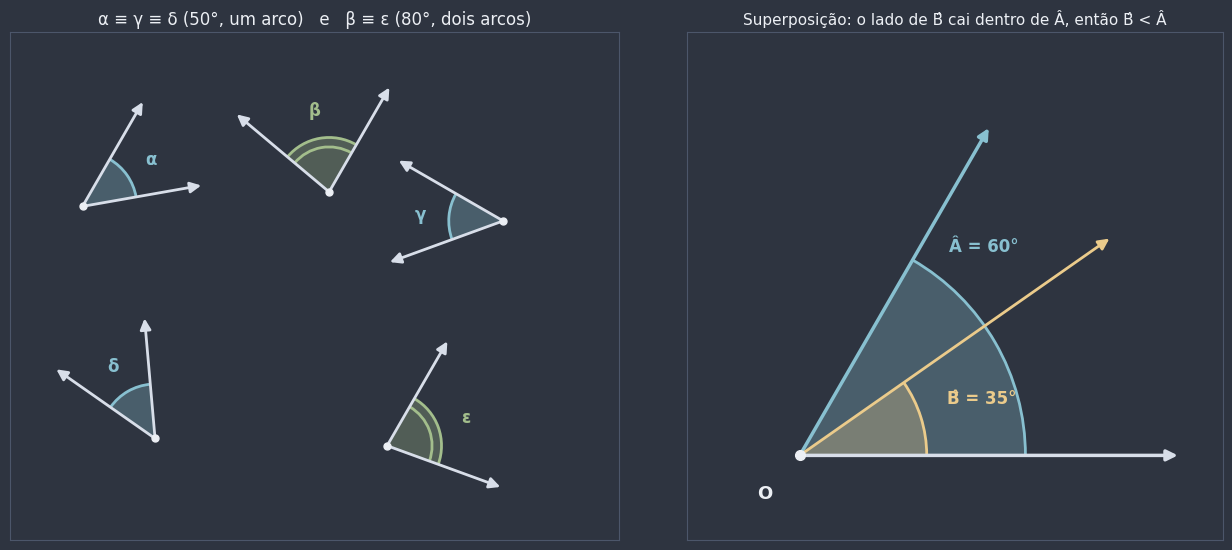

In [13]:
angulos_espalhados = {
    "α": ((-3.2, 1.0), 10, 50),
    "β": ((0.2, 1.2), 60, 80),
    "γ": ((2.6, 0.8), 150, 50),
    "δ": ((-2.2, -2.2), 95, 50),
    "ε": ((1.0, -2.3), -20, 80),
}
estilo_por_medida = {50: (COR_PONTO, 1), 80: (COR_DESTAQUE, 2)}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.6), gridspec_kw={"width_ratios": [1.35, 1]})
fig.patch.set_facecolor(NORD_FUNDO)

# Esquerda: ângulos congruentes espalhados pelo plano
preparar_eixo(ax1, 4.2)
ax1.set_ylim(-3.6, 3.4)
for nome, (vertice, inicio, medida) in angulos_espalhados.items():
    cor, arcos = estilo_por_medida[medida]
    desenhar_angulo(ax1, vertice, inicio, medida, raio=0.75, cor=cor, arcos=arcos, rotulo=nome, raio_rotulo=1.15)
    desenhar_semirreta(ax1, vertice, inicio, comprimento=1.7, largura=2)
    desenhar_semirreta(ax1, vertice, inicio + medida, comprimento=1.7, largura=2)
    ax1.plot(*vertice, "o", color=NORD_TEXTO, markersize=5, zorder=5)
ax1.set_title("α ≡ γ ≡ δ (50°, um arco)   e   β ≡ ε (80°, dois arcos)", color=NORD_TEXTO, fontsize=12)

# Direita: comparação por superposição
preparar_eixo(ax2, 2.9)
ax2.set_xlim(-0.8, 3.0)
ax2.set_ylim(-0.6, 3.0)
o = (0, 0)
desenhar_angulo(ax2, o, 0, 60, raio=1.6, cor=COR_PONTO)
ax2.text(*(1.95 * direcao(48)), "Â = 60°", color=COR_PONTO, fontsize=12, fontweight="bold", ha="center")
desenhar_angulo(ax2, o, 0, 35, raio=0.9, cor=COR_AVISO, rotulo="B̂ = 35°", raio_rotulo=1.35)
desenhar_semirreta(ax2, o, 0, comprimento=2.7)
desenhar_semirreta(ax2, o, 60, comprimento=2.7, cor=COR_PONTO)
desenhar_semirreta(ax2, o, 35, comprimento=2.7, cor=COR_AVISO, largura=2)
desenhar_ponto(ax2, o, "O", cor=NORD_TEXTO, deslocamento=(-0.3, -0.3))
ax2.set_title("Superposição: o lado de B̂ cai dentro de Â, então B̂ < Â", color=NORD_TEXTO, fontsize=11)

plt.tight_layout()
plt.show()

💡 **Dica:** assim como nos segmentos, "congruente" **não** quer dizer "no mesmo lugar do plano". No desenho, α, γ e δ estão em lugares diferentes, virados para lados diferentes, e são congruentes porque têm a **mesma medida**. Girar ou arrastar um ângulo não muda sua medida.

🕹️ **Widget interativo:** escolha as medidas de $\hat{A}$ e $\hat{B}$. Os dois ângulos são desenhados em posições diferentes de propósito ($\hat{B}$ está sempre girado). Quando as medidas coincidem, os dois ficam verdes e ganham dois arcos.

In [14]:
def comparar_dois_angulos(medida_a: float, medida_b: float) -> None:
    congruentes = math.isclose(medida_a, medida_b)
    cor_a = COR_DESTAQUE if congruentes else COR_PONTO
    cor_b = COR_DESTAQUE if congruentes else COR_EXTRA
    arcos = 2 if congruentes else 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.6))
    fig.patch.set_facecolor(NORD_FUNDO)
    for ax, medida, inicio, cor, nome in [(ax1, medida_a, 0, cor_a, "Â"), (ax2, medida_b, 40, cor_b, "B̂")]:
        preparar_eixo(ax, 2.9)
        desenhar_angulo(ax, (0, 0), inicio, medida, raio=0.9, cor=cor, arcos=arcos, marcar_reto=False)
        desenhar_semirreta(ax, (0, 0), inicio, comprimento=2.5)
        desenhar_semirreta(ax, (0, 0), inicio + medida, comprimento=2.5)
        ax.plot(0, 0, "o", color=NORD_TEXTO, markersize=6, zorder=5)
        ax.set_title(f"{nome} = {medida:g}°", color=cor, fontsize=13)

    relacao = comparar_angulos(medida_a, medida_b)
    if congruentes:
        texto, cor_titulo = "Â ≡ B̂: congruentes ✓", COR_DESTAQUE
    else:
        texto, cor_titulo = f"Â {relacao} B̂ (diferença de {abs(medida_a - medida_b):g}°)", COR_AVISO
    fig.suptitle(texto, color=cor_titulo, fontsize=14)
    plt.tight_layout()
    plt.show()


widgets.interact(
    comparar_dois_angulos,
    medida_a=widgets.IntSlider(value=70, min=5, max=180, step=5, description="medida de Â:"),
    medida_b=widgets.IntSlider(value=110, min=5, max=180, step=5, description="medida de B̂:"),
);

interactive(children=(IntSlider(value=70, description='medida de Â:', max=180, min=5, step=5), IntSlider(value…

**Pergunta de checagem:** dois ângulos retos são sempre congruentes entre si? Por quê? E dois ângulos agudos, também são sempre congruentes?

**Pergunta de checagem:** um ângulo mede 45° 30′ e outro mede 45,3°. Eles são congruentes? (Cuidado com a vírgula!)

## 4. Ângulos consecutivos, adjacentes, complementares e suplementares

Até aqui olhamos um ângulo de cada vez. Quando aparecem **dois** ângulos juntos, algumas relações entre eles ganham nome. Duas delas falam da **posição** dos ângulos, e duas falam da **soma das medidas**.

**Relações de posição:**

📌 **Ângulos consecutivos:** têm o **mesmo vértice** e **um lado em comum**.

📌 **Ângulos adjacentes:** são consecutivos e **não têm pontos internos em comum**, ou seja, ficam um "ao lado" do outro, sem se sobrepor. (É o mesmo espírito dos segmentos adjacentes, que ficavam um em continuação do outro.)

**Relações de medida:**

📌 **Ângulos complementares:** a soma das medidas é **90°**. Cada um é o **complemento** do outro: o complemento de $x$ é $90^\circ - x$.

📌 **Ângulos suplementares:** a soma das medidas é **180°**. Cada um é o **suplemento** do outro: o suplemento de $x$ é $180^\circ - x$.

Como os ângulos têm medida positiva, só existe complemento para $0^\circ < x < 90^\circ$ (ângulos agudos) e só existe suplemento para $0^\circ < x < 180^\circ$.

| Relação | É sobre... | Condição |
|---|---|---|
| consecutivos | posição | mesmo vértice e um lado em comum |
| adjacentes | posição | consecutivos **e** sem sobreposição |
| complementares | medida | soma = 90° |
| suplementares | medida | soma = 180° |

Veja seis casos, lado a lado. Os dois de baixo têm **vértices diferentes**: não são consecutivos nem adjacentes, mas continuam podendo ser complementares ou suplementares.

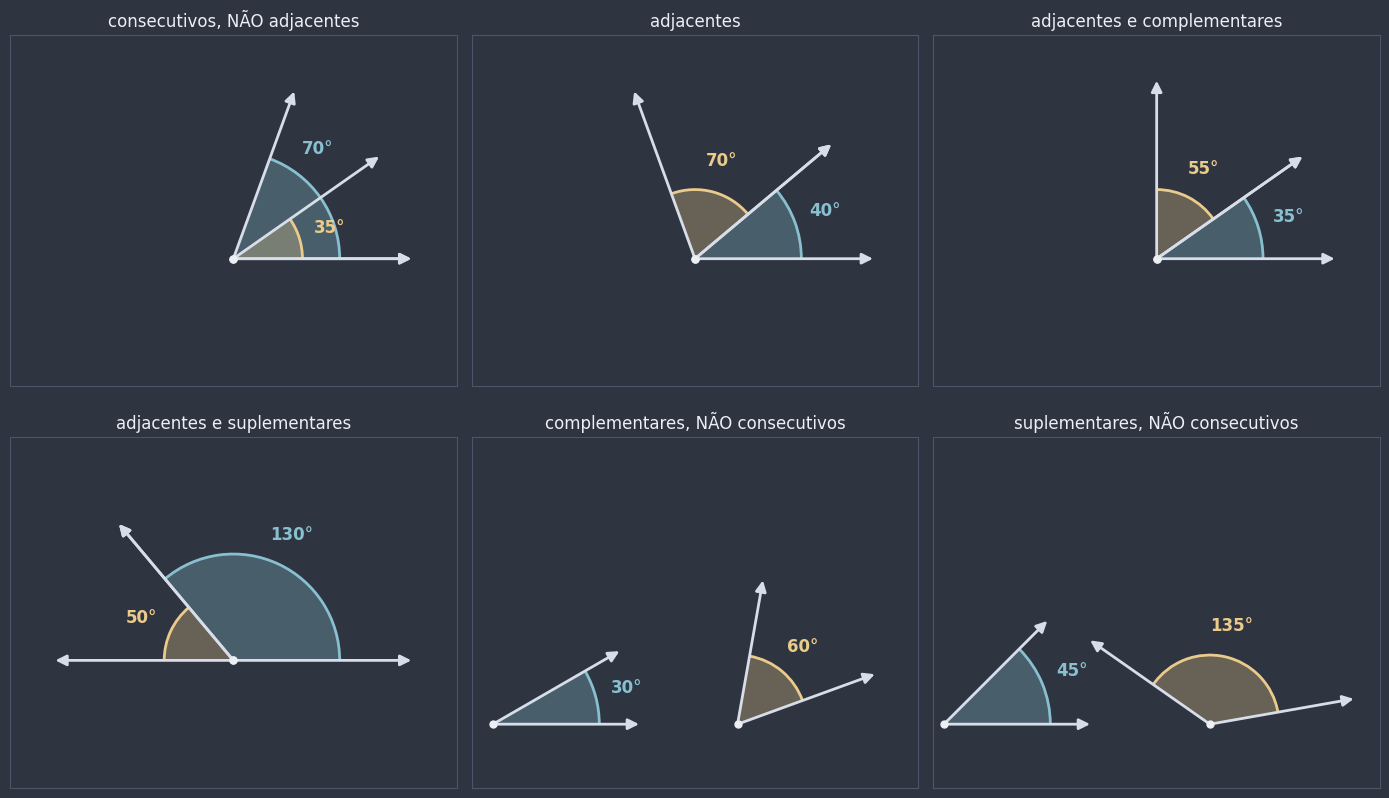

In [15]:
# Um ângulo é descrito por (vértice, direção do 1º lado, direção do 2º lado), com as direções em graus
casos_de_posicao = [
    ("consecutivos, NÃO adjacentes", [((0, 0), 0, 70), ((0, 0), 0, 35)]),
    ("adjacentes", [((0, 0), 0, 40), ((0, 0), 40, 110)]),
    ("adjacentes e complementares", [((0, 0), 0, 35), ((0, 0), 35, 90)]),
    ("adjacentes e suplementares", [((0, 0), 0, 130), ((0, 0), 130, 180)]),
    ("complementares, NÃO consecutivos", [((-1.9, -0.6), 0, 30), ((0.4, -0.6), 20, 80)]),
    ("suplementares, NÃO consecutivos", [((-2.0, -0.6), 0, 45), ((0.5, -0.6), 10, 145)]),
]
cores_do_par = [COR_PONTO, COR_AVISO]


def desenhar_par_de_angulos(ax, par: list, raios=(1.0, 0.65)) -> None:
    """Desenha dois ângulos (cada um dado por vértice e direções dos lados) com suas medidas."""
    vertices_diferentes = par[0][0] != par[1][0]
    for k, ((vertice, inicio, fim), cor, raio) in enumerate(zip(par, cores_do_par, raios)):
        medida = fim - inicio
        desenhar_angulo(ax, vertice, inicio, medida, raio=raio, cor=cor)
        # Se o outro ângulo está dentro deste, o rótulo vai para a parte que sobra livre
        v_outro, ini_outro, fim_outro = par[1 - k]
        meio = (inicio + fim) / 2
        if v_outro == vertice and inicio <= ini_outro and fim_outro <= fim and fim_outro - ini_outro < medida:
            meio = (fim_outro + fim) / 2 if ini_outro == inicio else (inicio + ini_outro) / 2
        posicao = np.array(vertice) + (raio + 0.3) * direcao(meio)
        ax.text(*posicao, f"{medida}°", color=cor, fontsize=12, ha="center", va="center", fontweight="bold")
        for lado in (inicio, fim):
            desenhar_semirreta(ax, vertice, lado, comprimento=1.4 if vertices_diferentes else 1.7, largura=2)
        ax.plot(*vertice, "o", color=NORD_TEXTO, markersize=5, zorder=5)


fig, eixos = plt.subplots(2, 3, figsize=(14, 8.4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (titulo, par) in zip(eixos.flat, casos_de_posicao):
    preparar_eixo(ax, 2.1)
    ax.set_ylim(-1.2, 2.1)
    desenhar_par_de_angulos(ax, par)
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

No primeiro caso, os dois ângulos de 70° e 35° têm o vértice e o lado de 0° em comum (consecutivos), mas o de 35° está **dentro** do de 70°: eles têm muitos pontos internos em comum, por isso não são adjacentes.

As quatro definições viram código. Para decidir se dois ângulos consecutivos se **sobrepõem**, olhamos para as direções dos lados como se fossem intervalos, do mesmo jeito que segmentos na reta numerada: se os intervalos só se tocam na borda (o lado comum), não há sobreposição.

In [16]:
def classificar_par_de_angulos(angulo_1: tuple, angulo_2: tuple) -> dict[str, bool]:
    """Classifica dois ângulos dados como (vértice, direção do 1º lado, direção do 2º lado)."""
    (v1, ini1, fim1), (v2, ini2, fim2) = angulo_1, angulo_2
    lados_comuns = {ini1, fim1} & {ini2, fim2}
    consecutivos = v1 == v2 and len(lados_comuns) == 1
    # "tamanho" da parte comum entre os intervalos de direções; se for <= 0, não há sobreposição
    sobreposicao = min(fim1, fim2) - max(ini1, ini2)
    adjacentes = consecutivos and sobreposicao <= 0
    soma = (fim1 - ini1) + (fim2 - ini2)
    return {
        "consecutivos": consecutivos,
        "adjacentes": adjacentes,
        "complementares": math.isclose(soma, 90),
        "suplementares": math.isclose(soma, 180),
    }


linhas = []
for titulo, (ang_1, ang_2) in casos_de_posicao:
    resultado = classificar_par_de_angulos(ang_1, ang_2)
    linhas.append({"caso": titulo, **{k: marca(v) for k, v in resultado.items()}})
display(pd.DataFrame(linhas).style.hide(axis="index"))

caso,consecutivos,adjacentes,complementares,suplementares
"consecutivos, NÃO adjacentes",✅,❌,❌,❌
adjacentes,✅,✅,❌,❌
adjacentes e complementares,✅,✅,✅,❌
adjacentes e suplementares,✅,✅,❌,✅
"complementares, NÃO consecutivos",❌,❌,✅,❌
"suplementares, NÃO consecutivos",❌,❌,❌,✅


Agora o complemento e o suplemento. A função devolve `None` (o "nada" do Python) quando o complemento ou o suplemento **não existe**:

In [17]:
def complemento(medida: float) -> float | None:
    """Devolve o complemento (90° - medida) ou None se ele não existir."""
    return 90 - medida if 0 < medida < 90 else None


def suplemento(medida: float) -> float | None:
    """Devolve o suplemento (180° - medida) ou None se ele não existir."""
    return 180 - medida if 0 < medida < 180 else None


medidas = [20, 35, 45, 60, 89.5, 90, 120, 179, 180]
tabela_comp_sup = pd.DataFrame({
    "x": medidas,
    "classificação": [classificar_angulo(m) for m in medidas],
    "complemento (90° − x)": [complemento(m) for m in medidas],
    "suplemento (180° − x)": [suplemento(m) for m in medidas],
})
display(
    tabela_comp_sup.style.format(
        {"x": "{:g}°", "complemento (90° − x)": "{:g}°", "suplemento (180° − x)": "{:g}°"}, na_rep="não existe"
    ).hide(axis="index")
)

x,classificação,complemento (90° − x),suplemento (180° − x)
20°,agudo,70°,160°
35°,agudo,55°,145°
45°,agudo,45°,135°
60°,agudo,30°,120°
89.5°,agudo,0.5°,90.5°
90°,reto,não existe,90°
120°,obtuso,não existe,60°
179°,obtuso,não existe,1°
180°,raso,não existe,não existe


Um problema clássico de prova: **"o suplemento de um ângulo é o triplo do seu complemento. Quanto mede o ângulo?"** Chamando o ângulo de $x$:

$$180 - x = 3\,(90 - x) \implies 180 - x = 270 - 3x \implies 2x = 90 \implies x = 45^\circ$$

Conferindo: o complemento de 45° é 45°, o suplemento é 135°, e $135 = 3 \cdot 45$. ✓ O Python também pode "caçar" a resposta testando todos os ângulos agudos inteiros:

Ângulos inteiros que satisfazem 'suplemento = 3 × complemento': [45]


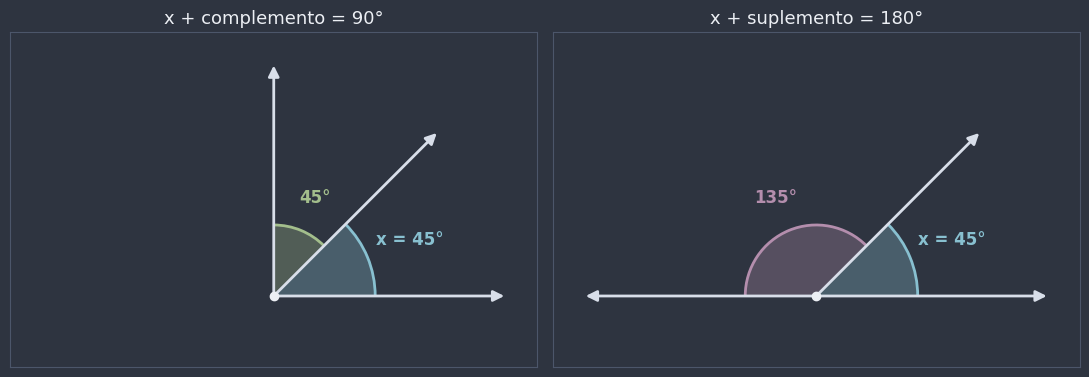

In [18]:
candidatos = [x for x in range(1, 90) if suplemento(x) == 3 * complemento(x)]
print(f"Ângulos inteiros que satisfazem 'suplemento = 3 × complemento': {candidatos}")

# Desenho: 45° junto com seu complemento (formando um reto) e com seu suplemento (formando um raso)
x = 45
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, parceiro, nome in [(ax1, complemento(x), "complemento"), (ax2, suplemento(x), "suplemento")]:
    preparar_eixo(ax, 2.6)
    ax.set_ylim(-0.7, 2.6)
    desenhar_angulo(ax, (0, 0), 0, x, raio=1.0, cor=COR_PONTO, rotulo=f"x = {x}°", raio_rotulo=1.45)
    desenhar_angulo(ax, (0, 0), x, parceiro, raio=0.7, cor=COR_DESTAQUE if nome == "complemento" else COR_EXTRA,
                    rotulo=f"{parceiro}°", raio_rotulo=1.05)
    for lado in (0, x, x + parceiro):
        desenhar_semirreta(ax, (0, 0), lado, comprimento=2.3, largura=2)
    ax.plot(0, 0, "o", color=NORD_TEXTO, markersize=6, zorder=5)
    ax.set_title(f"x + {nome} = {x + parceiro}°", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

🎯 **Aplicação prática — plantas baixas e cantos de parede:** numa planta baixa, as paredes de um cômodo retangular se encontram em ângulos retos. Quando um arquiteto coloca uma parede **inclinada** (uma divisória diagonal, por exemplo), aparecem ângulos complementares e suplementares por todo lado: a divisória **divide o canto reto** em dois ângulos complementares, e, onde ela encontra uma parede reta, forma com ela dois ângulos suplementares (um de cada lado). Saber um desses ângulos já dá todos os outros, sem precisar medir de novo.

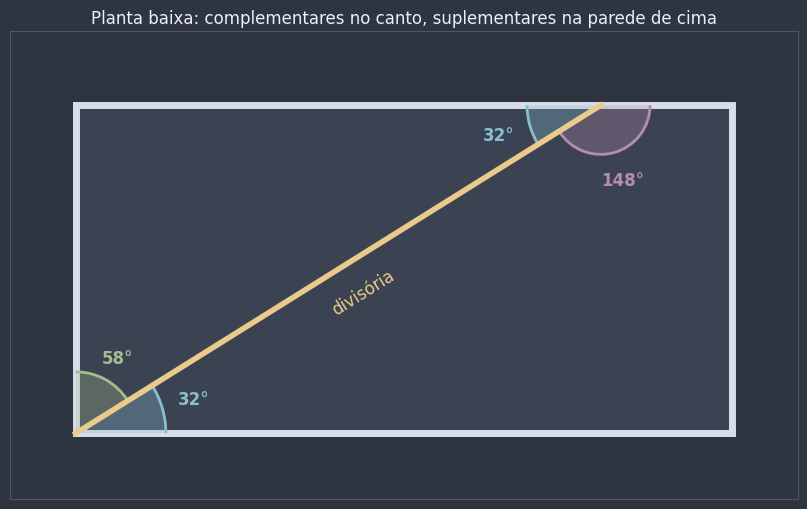

No canto:          32° + 58° = 90°  (complementares)
Na parede de cima: 32° + 148° = 180° (suplementares)


In [19]:
largura, profundidade = 8.0, 4.0
angulo_divisoria = 32  # ângulo entre a parede de baixo e a divisória, no canto (0, 0)

# A divisória sai do canto (0, 0) e vai até a parede de cima (y = profundidade)
x_encontro = profundidade / math.tan(math.radians(angulo_divisoria))
canto = np.array([0.0, 0.0])
encontro = np.array([x_encontro, profundidade])

fig, ax = plt.subplots(figsize=(10, 5.2))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.grid(False)
ax.set_aspect("equal")
ax.set_xlim(-0.8, largura + 0.8)
ax.set_ylim(-0.8, profundidade + 0.9)
ax.set_xticks([])
ax.set_yticks([])
ax.add_patch(plt.Rectangle((0, 0), largura, profundidade, facecolor=NORD_PAINEL, edgecolor=NORD_TEXTO_SEC, lw=5))
ax.plot(*zip(canto, encontro), color=COR_AVISO, lw=4)

# No canto: o ângulo reto é dividido em dois ângulos complementares
desenhar_angulo(ax, canto, 0, angulo_divisoria, raio=1.1, cor=COR_PONTO, rotulo=f"{angulo_divisoria}°", raio_rotulo=1.5)
desenhar_angulo(ax, canto, angulo_divisoria, 90 - angulo_divisoria, raio=0.75, cor=COR_DESTAQUE,
                rotulo=f"{90 - angulo_divisoria}°", raio_rotulo=1.05)
# No encontro com a parede de cima: dois ângulos suplementares
desenhar_angulo(ax, encontro, 180, angulo_divisoria, raio=0.9, cor=COR_PONTO, rotulo=f"{angulo_divisoria}°", raio_rotulo=1.3)
desenhar_angulo(ax, encontro, 180 + angulo_divisoria, 180 - angulo_divisoria, raio=0.6, cor=COR_EXTRA,
                rotulo=f"{180 - angulo_divisoria}°", raio_rotulo=0.95)
ax.text(*((canto + encontro) / 2 + np.array([0.3, -0.55])), "divisória", color=COR_AVISO, fontsize=12,
        rotation=angulo_divisoria, ha="center")
ax.set_title("Planta baixa: complementares no canto, suplementares na parede de cima", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

print(f"No canto:          {angulo_divisoria}° + {90 - angulo_divisoria}° = 90°  (complementares)")
print(f"Na parede de cima: {angulo_divisoria}° + {180 - angulo_divisoria}° = 180° (suplementares)")

📎 **Conexão:** o ângulo de 32° aparece **duas vezes** no desenho (no canto e na parede de cima). Isso não é coincidência: acontece porque as paredes de cima e de baixo são **paralelas**, e é exatamente o assunto do notebook 📌 Paralelismo (ângulos formados por uma transversal cortando duas paralelas).

🕹️ **Widget interativo:** escolha um ângulo $x$. À esquerda, o complemento é desenhado ao lado dele, completando um ângulo reto; à direita, o suplemento completa um ângulo raso. Passe de 90° e veja o complemento **desaparecer**: não sobra espaço até o ângulo reto.

In [ ]:
def complemento_e_suplemento(x: float) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
    fig.patch.set_facecolor(NORD_FUNDO)
    for ax, total, parceiro, nome, cor in [
        (ax1, 90, complemento(x), "complemento", COR_DESTAQUE),
        (ax2, 180, suplemento(x), "suplemento", COR_EXTRA),
    ]:
        preparar_eixo(ax, 2.6)
        ax.set_ylim(-1.2, 2.6)
        # linha-guia pontilhada até o reto (90°) ou o raso (180°)
        ax.plot(*zip((0, 0), 2.3 * direcao(total)), color=NORD_LINHA, lw=1.5, linestyle="--")
        desenhar_angulo(ax, (0, 0), 0, x, raio=1.0, cor=COR_PONTO, marcar_reto=False)
        desenhar_semirreta(ax, (0, 0), 0, comprimento=2.3, largura=2)
        desenhar_semirreta(ax, (0, 0), x, comprimento=2.3, largura=2)
        if parceiro is not None:
            desenhar_angulo(ax, (0, 0), x, parceiro, raio=0.7, cor=cor, marcar_reto=False)
            ax.set_title(f"{nome} de {x:g}° = {parceiro:g}°", color=cor, fontsize=13)
        else:
            ax.set_title(f"{x:g}° ≥ {total}°: não existe {nome}", color=COR_ALERTA, fontsize=13)
        ax.plot(0, 0, "o", color=NORD_TEXTO, markersize=6, zorder=5)
    plt.tight_layout()
    plt.show()


widgets.interact(
    complemento_e_suplemento,
    x=widgets.IntSlider(value=30, min=1, max=179, step=1, description="x (°):"),
);

interactive(children=(IntSlider(value=30, description='x (°):', max=179, min=1), Output()), _dom_classes=('wid…

⚠️ **Erro comum:** achar que ângulos adjacentes são sempre complementares ou suplementares. Não são! **Adjacência** é sobre a **posição** (lado a lado, com vértice e um lado em comum); **complementar** e **suplementar** são sobre a **soma das medidas**. Na figura dos seis casos, os ângulos de 40° e 70° são adjacentes, mas somam 110°: nem complementares, nem suplementares. E os de 30° e 60° de baixo são complementares sem sequer terem o mesmo vértice.

📎 **Conexão:** lembra dos chutes de 15° e 75°, e de 30° e 60°, que tinham o mesmo alcance? São pares de ângulos **complementares**. Em [`0504a_reducao_ao_1o_quadrante.ipynb`](../05_trigonometria/0504a_reducao_ao_1o_quadrante.ipynb) você vai ver que o seno de um ângulo é igual ao cosseno do seu complemento, e é daí que vem essa coincidência.

**Pergunta de checagem:** um ângulo de 120° tem complemento? E suplemento? Se tiver, quanto mede?

**Pergunta de checagem:** dois ângulos adjacentes $A\hat{O}B$ e $B\hat{O}C$ são complementares. Que ângulo o lado $\overrightarrow{OA}$ forma com o lado $\overrightarrow{OC}$?

## 5. Ângulos opostos pelo vértice e bissetriz

**Duas retas que se cruzam.** Quando duas retas concorrentes se cruzam num ponto O, elas formam **quatro ângulos** em volta de O. Olhe para dois ângulos "de frente" um para o outro:

📌 **Ângulos opostos pelo vértice (o.p.v.):** dois ângulos com o mesmo vértice, em que os lados de um são as **semirretas opostas** aos lados do outro. Duas retas concorrentes formam **dois pares** de ângulos opostos pelo vértice.

E vale uma propriedade muito usada:

$$\text{ângulos opostos pelo vértice são sempre congruentes.}$$

Na figura abaixo, chamando os quatro ângulos de $\alpha$, $\beta$, $\gamma$ e $\delta$, em volta de O: $\alpha \equiv \gamma$ e $\beta \equiv \delta$. E, como dois ângulos vizinhos formam um ângulo raso (estão sobre uma das retas), eles são **suplementares**: $\alpha + \beta = 180^\circ$.

💡 **Aprofundamento (opcional) — por que opostos pelo vértice são congruentes?** Os ângulos $\alpha$ e $\beta$ estão lado a lado sobre a reta $r$, então $\alpha + \beta = 180^\circ$. Os ângulos $\beta$ e $\gamma$ estão lado a lado sobre a reta $s$, então $\beta + \gamma = 180^\circ$. As duas somas dão 180°, portanto $\alpha + \beta = \beta + \gamma$, e tirando $\beta$ dos dois lados: $\alpha = \gamma$. Esse é o seu primeiro **teorema** sobre ângulos, demonstrado só com suplementos!

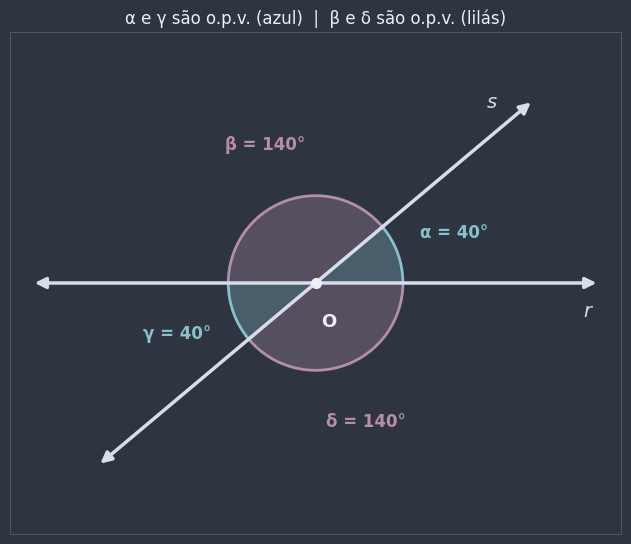

α,β,γ,δ,α ≡ γ?,β ≡ δ?,soma dos quatro
10°,170°,10°,170°,✅,✅,360°
40°,140°,40°,140°,✅,✅,360°
63°,117°,63°,117°,✅,✅,360°
90°,90°,90°,90°,✅,✅,360°
125°,55°,125°,55°,✅,✅,360°
170°,10°,170°,10°,✅,✅,360°


In [21]:
def angulos_de_retas_concorrentes(alfa: float) -> tuple[float, float, float, float]:
    """Dado um dos ângulos formados por duas retas concorrentes, devolve os quatro, em volta do vértice."""
    beta = 180 - alfa
    return alfa, beta, alfa, beta


alfa = 40
fig, ax = plt.subplots(figsize=(6.5, 5.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, 2.8)
ax.set_ylim(-2.3, 2.3)
nomes = ["α", "β", "γ", "δ"]
cores_opv = [COR_PONTO, COR_EXTRA, COR_PONTO, COR_EXTRA]
inicios = [0, alfa, 180, 180 + alfa]
for nome, cor, inicio, medida in zip(nomes, cores_opv, inicios, angulos_de_retas_concorrentes(alfa)):
    desenhar_angulo(ax, (0, 0), inicio, medida, raio=0.8, cor=cor, rotulo=f"{nome} = {medida}°", raio_rotulo=1.35)
desenhar_reta(ax, (0, 0), 0, comprimento=2.6)
desenhar_reta(ax, (0, 0), alfa, comprimento=2.6)
ax.text(2.45, -0.3, "r", color=NORD_TEXTO_SEC, fontsize=14, fontstyle="italic")
ax.text(*(2.5 * direcao(alfa) + np.array([-0.35, 0])), "s", color=NORD_TEXTO_SEC, fontsize=14, fontstyle="italic")
desenhar_ponto(ax, (0, 0), "O", cor=NORD_TEXTO, deslocamento=(0.05, -0.4))
ax.set_title("α e γ são o.p.v. (azul)  |  β e δ são o.p.v. (lilás)", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

linhas = []
for a in [10, 40, 63, 90, 125, 170]:
    angulos = angulos_de_retas_concorrentes(a)
    linhas.append({**dict(zip(nomes, angulos)), "α ≡ γ?": marca(angulos[0] == angulos[2]),
                   "β ≡ δ?": marca(angulos[1] == angulos[3]), "soma dos quatro": sum(angulos)})
display(pd.DataFrame(linhas).style.format({n: "{:g}°" for n in nomes} | {"soma dos quatro": "{:g}°"}).hide(axis="index"))

Repare na última coluna: a soma dos quatro ângulos em volta de O é sempre **360°**, uma volta completa. Isso vale para quaisquer ângulos que "fecham" uma volta em torno de um ponto, e vai aparecer num dos desafios.

**Bissetriz.** Agora, a ferramenta para dividir um ângulo ao meio.

📌 **Definição formal (bissetriz):** a **bissetriz** de um ângulo $A\hat{O}B$ é a semirreta $\overrightarrow{OC}$, com origem no vértice, que divide o ângulo em dois ângulos **congruentes**: $A\hat{O}C \equiv C\hat{O}B$. Ela é o **eixo de simetria** do ângulo: dobrando o papel sobre a bissetriz, um lado cai exatamente sobre o outro.

Consequências diretas:
- cada metade mede $\dfrac{m(A\hat{O}B)}{2}$;
- se o lado $\overrightarrow{OA}$ está na direção $a$ e o lado $\overrightarrow{OB}$ na direção $b$ (com $a < b$), a bissetriz está na direção **média**: $\dfrac{a + b}{2}$ (igualzinho ao ponto médio de um segmento!);
- traçando a bissetriz de cada metade, o ângulo fica dividido em **4** partes congruentes; repetindo, em **8**, **16**...

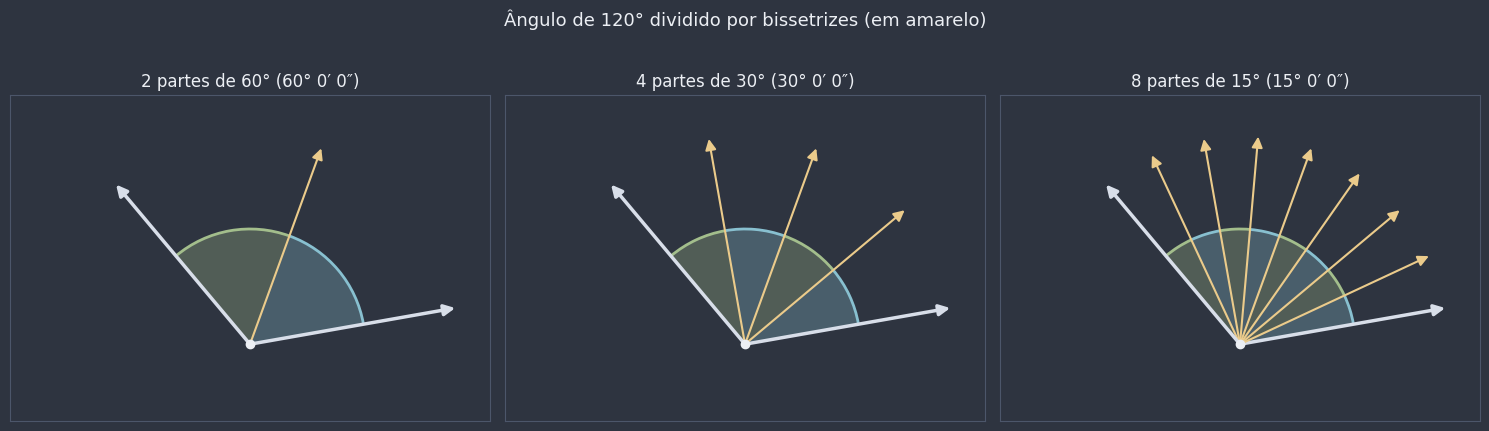

ângulo,metade (bissetriz),quarta parte,oitava parte
120° 0′ 0″,60° 0′ 0″,30° 0′ 0″,15° 0′ 0″
90° 0′ 0″,45° 0′ 0″,22° 30′ 0″,11° 15′ 0″
75° 0′ 0″,37° 30′ 0″,18° 45′ 0″,9° 22′ 30″
47° 30′ 0″,23° 45′ 0″,11° 52′ 30″,5° 56′ 15″
13° 0′ 0″,6° 30′ 0″,3° 15′ 0″,1° 37′ 30″


In [22]:
def direcao_bissetriz(dir_a: float, dir_b: float) -> float:
    """Direção da bissetriz do ângulo com lados nas direções dir_a < dir_b (em graus)."""
    return (dir_a + dir_b) / 2


def dividir_com_bissetrizes(dir_a: float, dir_b: float, vezes: int) -> list[float]:
    """Direções de todos os lados depois de traçar bissetrizes `vezes` vezes seguidas (2**vezes partes)."""
    lados = [dir_a, dir_b]
    for _ in range(vezes):
        novos = [lados[0]]
        for esquerdo, direito in zip(lados[:-1], lados[1:]):
            novos += [direcao_bissetriz(esquerdo, direito), direito]
        lados = novos
    return lados


fig, eixos = plt.subplots(1, 3, figsize=(15, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
dir_a, dir_b = 10, 130
cores_partes = [COR_PONTO, COR_DESTAQUE]
for ax, vezes in zip(eixos, [1, 2, 3]):
    preparar_eixo(ax, 2.5)
    ax.set_ylim(-0.8, 2.6)
    lados = dividir_com_bissetrizes(dir_a, dir_b, vezes)
    parte = (dir_b - dir_a) / 2**vezes
    for k, (esquerdo, direito) in enumerate(zip(lados[:-1], lados[1:])):
        desenhar_angulo(ax, (0, 0), esquerdo, direito - esquerdo, raio=1.2, cor=cores_partes[k % 2], marcar_reto=False)
    for k, lado in enumerate(lados):
        eh_lado_original = k in (0, len(lados) - 1)
        desenhar_semirreta(ax, (0, 0), lado, comprimento=2.2, cor=NORD_TEXTO_SEC if eh_lado_original else COR_AVISO,
                           largura=2.5 if eh_lado_original else 1.5)
    ax.plot(0, 0, "o", color=NORD_TEXTO, markersize=6, zorder=5)
    ax.set_title(f"{2**vezes} partes de {parte:g}° ({formatar_gms(parte)})", color=NORD_TEXTO, fontsize=12)
fig.suptitle(f"Ângulo de {dir_b - dir_a}° dividido por bissetrizes (em amarelo)", color=NORD_TEXTO, fontsize=13)
plt.tight_layout()
plt.show()

medidas = [120, 90, 75, para_graus_decimais(47, 30), 13]
tabela_bissetriz = pd.DataFrame({
    "ângulo": [formatar_gms(m) for m in medidas],
    "metade (bissetriz)": [formatar_gms(m / 2) for m in medidas],
    "quarta parte": [formatar_gms(m / 4) for m in medidas],
    "oitava parte": [formatar_gms(m / 8) for m in medidas],
})
display(tabela_bissetriz.style.hide(axis="index"))

🕵️ **Curiosidade histórica:** com régua e compasso, os gregos antigos sabiam traçar a bissetriz de qualquer ângulo e, portanto, dividi-lo em 2, 4, 8, 16... partes iguais. Mas dividir um ângulo qualquer em **3** partes iguais (a **trissecção do ângulo**) resistiu a eles e a todos os matemáticos por mais de 2000 anos. Só em 1837 o francês Pierre Wantzel provou que essa construção é **impossível** só com régua (sem marcações) e compasso. No computador, é claro, basta dividir a medida por 3.

🎯 **Aplicação prática — a luz num espelho:** quando um raio de luz bate num espelho plano, ele é refletido de um jeito bem simétrico. Traçando a **normal** (a reta perpendicular ao espelho no ponto onde a luz bate), o ângulo de incidência $i$ e o ângulo de reflexão $r$ são **congruentes**. Isso quer dizer que a normal é a **bissetriz** do ângulo formado pelo raio que chega e pelo raio que sai. A mesma ideia vale para uma bola de sinuca batendo na tabela (sem efeito).

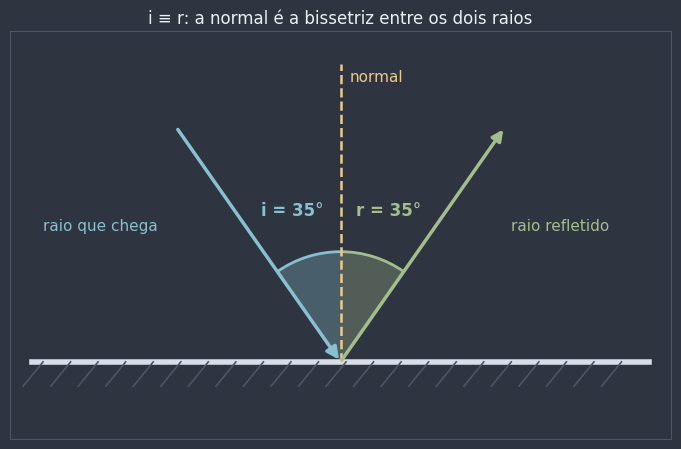

In [23]:
angulo_incidencia = 35

fig, ax = plt.subplots(figsize=(7.5, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, 3.0)
ax.set_ylim(-0.7, 3.0)
o = (0, 0)

# Espelho, com os risquinhos embaixo indicando a parte de trás
ax.plot([-2.8, 2.8], [0, 0], color=NORD_TEXTO_SEC, lw=4)
for x in np.arange(-2.7, 2.8, 0.25):
    ax.plot([x, x - 0.18], [0, -0.22], color=NORD_LINHA, lw=1.2)
# Normal (bissetriz)
ax.plot([0, 0], [0, 2.7], color=COR_AVISO, lw=1.8, linestyle="--")
ax.text(0.08, 2.55, "normal", color=COR_AVISO, fontsize=11)

# Raio que chega e raio que sai
origem_raio = 2.6 * direcao(90 + angulo_incidencia)
ax.annotate("", xy=o, xytext=origem_raio, arrowprops=dict(arrowstyle="-|>", color=COR_PONTO, lw=2.5, mutation_scale=18))
desenhar_semirreta(ax, o, 90 - angulo_incidencia, comprimento=2.6, cor=COR_DESTAQUE)
desenhar_angulo(ax, o, 90, angulo_incidencia, raio=1.0, cor=COR_PONTO, rotulo=f"i = {angulo_incidencia}°", raio_rotulo=1.45)
desenhar_angulo(ax, o, 90 - angulo_incidencia, angulo_incidencia, raio=1.0, cor=COR_DESTAQUE,
                rotulo=f"r = {angulo_incidencia}°", raio_rotulo=1.45)
ax.text(-2.7, 1.2, "raio que chega", color=COR_PONTO, fontsize=11)
ax.text(1.55, 1.2, "raio refletido", color=COR_DESTAQUE, fontsize=11)
ax.set_title("i ≡ r: a normal é a bissetriz entre os dois raios", color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** mude o ângulo entre as retas $r$ e $s$ e observe os quatro ângulos. Os opostos pelo vértice têm sempre a **mesma cor e a mesma medida**, não importa a posição. Depois marque a caixa `mostrar bissetrizes`: aparecem as bissetrizes dos quatro ângulos. Qual é o ângulo entre elas? Ele muda quando você mexe no slider?

In [ ]:
def retas_concorrentes(alfa: float, mostrar_bissetrizes: bool) -> None:
    fig, ax = plt.subplots(figsize=(6.5, 5.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    preparar_eixo(ax, 2.8)
    medidas = angulos_de_retas_concorrentes(alfa)
    inicios = [0, alfa, 180, 180 + alfa]
    for nome, cor, inicio, medida in zip(nomes, cores_opv, inicios, medidas):
        desenhar_angulo(ax, (0, 0), inicio, medida, raio=0.75, cor=cor, rotulo=f"{nome}={medida:g}°",
                        raio_rotulo=1.35, marcar_reto=False)
    desenhar_reta(ax, (0, 0), 0, comprimento=2.6)
    desenhar_reta(ax, (0, 0), alfa, comprimento=2.6)
    if mostrar_bissetrizes:
        dir_1, dir_2 = direcao_bissetriz(0, alfa), direcao_bissetriz(alfa, 180)
        for d in (dir_1, dir_2):
            ax.plot(*zip(-2.4 * direcao(d), 2.4 * direcao(d)), color=COR_AVISO, lw=1.8, linestyle="--")
        desenhar_angulo(ax, (0, 0), dir_1, dir_2 - dir_1, raio=0.45, cor=COR_AVISO)
        titulo = f"Ângulo entre as bissetrizes: {dir_2 - dir_1:g}°"
    else:
        titulo = f"α ≡ γ = {medidas[0]:g}°   |   β ≡ δ = {medidas[1]:g}°"
    ax.plot(0, 0, "o", color=NORD_TEXTO, markersize=6, zorder=5)
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=12)
    plt.tight_layout()
    plt.show()


widgets.interact(
    retas_concorrentes,
    alfa=widgets.IntSlider(value=40, min=5, max=175, step=5, description="α (°):"),
    mostrar_bissetrizes=widgets.Checkbox(value=False, description="mostrar bissetrizes"),
);

interactive(children=(IntSlider(value=40, description='α (°):', max=175, min=5, step=5), Checkbox(value=False,…

📎 **Conexão:** o ângulo entre as bissetrizes deu sempre 90° porque metade de $\alpha$ mais metade de $\beta$ é metade de 180°. Retas que formam ângulo reto são o assunto de 📌 Perpendicularidade. E os ângulos opostos pelo vértice voltam com força em 📌 Paralelismo, quando uma reta **transversal** corta duas retas paralelas e forma **oito** ângulos, que vão se relacionar por o.p.v., suplementos e mais algumas regras novas.

📖 **Leitura complementar:** [Bissetriz](https://pt.wikipedia.org/wiki/Bissetriz)

**Pergunta de checagem:** se um dos ângulos formados por duas retas concorrentes mede 40°, quais são as medidas dos outros três?

**Pergunta de checagem:** que ângulo a bissetriz de um ângulo **raso** forma com cada um dos lados dele? E com que nome você já conhecia essa semirreta?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Ângulo | região do plano limitada por duas semirretas de mesma origem; **vértice** = origem, **lados** = semirretas |
| Notação | $A\hat{O}B$ (vértice no meio), $\hat{O}$, ou letra grega ($\alpha$, $\beta$...); $A\hat{O}B = B\hat{O}A$ |
| Unidades | 1 volta = 360°; $1^\circ = 60'$; $1' = 60''$; $1^\circ = 3600''$ |
| Conversão | $g^\circ\, m'\, s'' = g + \frac{m}{60} + \frac{s}{3600}$ graus |
| Classificação | nulo (0°), **agudo** (< 90°), **reto** (= 90°), **obtuso** (entre 90° e 180°), **raso** (= 180°), côncavo (entre 180° e 360°), **giro** (= 360°) |
| Congruência | $\hat{A} \equiv \hat{B} \iff m(\hat{A}) = m(\hat{B})$; mesma quantidade de arcos no desenho |
| Consecutivos | mesmo vértice e **um lado em comum** |
| Adjacentes | consecutivos **e** sem pontos internos em comum |
| Complementares | soma = **90°**; complemento de $x$ = $90^\circ - x$ (só existe se $0^\circ < x < 90^\circ$) |
| Suplementares | soma = **180°**; suplemento de $x$ = $180^\circ - x$ (só existe se $0^\circ < x < 180^\circ$) |
| Opostos pelo vértice | lados de um são as semirretas opostas aos lados do outro; **sempre congruentes** |
| Retas concorrentes | 4 ângulos: $\alpha, \beta, \alpha, \beta$ com $\alpha + \beta = 180^\circ$; soma total 360° |
| Bissetriz | semirreta pelo vértice que divide o ângulo em **duas partes congruentes**; cada parte mede a metade; direção média dos lados |
| Em volta de um ponto | ângulos que completam uma volta somam **360°** |

**A ideia central:** um ângulo mede **abertura**, não tamanho. Com a medida em graus, todas as relações viram contas simples: congruência é igualdade, complemento e suplemento são subtrações, bissetriz é divisão por 2, e opostos pelo vértice são iguais porque têm o mesmo suplemento.

## Exercícios

**Básico**
1. Classificar uma lista de ângulos pela medida (agudo, reto, obtuso, raso ou giro).
2. Identificar, em desenhos, pares de ângulos consecutivos, adjacentes, complementares e suplementares.

**Intermediário**
3. Escrever funções que calculam o complemento e o suplemento de um ângulo, avisando quando eles não existem.
4. Dada a medida de um dos ângulos formados por duas retas concorrentes, calcular os outros três.

**Desafio**
5. Encontrar a direção da bissetriz e as medidas dos dois ângulos que ela forma, verificando que são congruentes.
6. Encontrar o ângulo que falta para completar uma volta em torno de um ponto.

Gabarito completo com resolução comentada em [`0403b_angulos_gabarito.ipynb`](0403b_angulos_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: classifique cada ângulo da lista `medidas_ex1` como
# "agudo", "reto", "obtuso", "raso" ou "giro" (em minúsculas).
# Responda com uma lista de textos, na mesma ordem das medidas.
medidas_ex1 = [72, 90, 135.5, 180, 360, 89.9, 90.25, 5]

classificacoes_ex1 = [..., ..., ..., ..., ..., ..., ..., ...]

print(classificacoes_ex1)

In [ ]:
# Verificação
gabarito_ex1 = ["agudo", "reto", "obtuso", "raso", "giro", "agudo", "obtuso", "agudo"]
assert classificacoes_ex1 is not ... and len(classificacoes_ex1) == len(medidas_ex1), (
    "Tente de novo, revise: a lista precisa ter uma classificação para cada uma das "
    f"{len(medidas_ex1)} medidas (seção 2 - Medida e classificação de ângulos)."
)
for medida, resposta, certa in zip(medidas_ex1, classificacoes_ex1, gabarito_ex1):
    assert isinstance(resposta, str) and resposta.strip().lower() == certa, (
        f"Tente de novo, revise: o ângulo de {medida:g}° foi classificado errado; compare "
        "com 90°, 180° e 360° (exatamente 90° é reto, abaixo é agudo, entre 90° e 180° é "
        "obtuso) (seção 2 - Medida e classificação de ângulos)."
    )
print("Certo!")

Execute a célula abaixo para ver os desenhos do Exercício Básico 2.

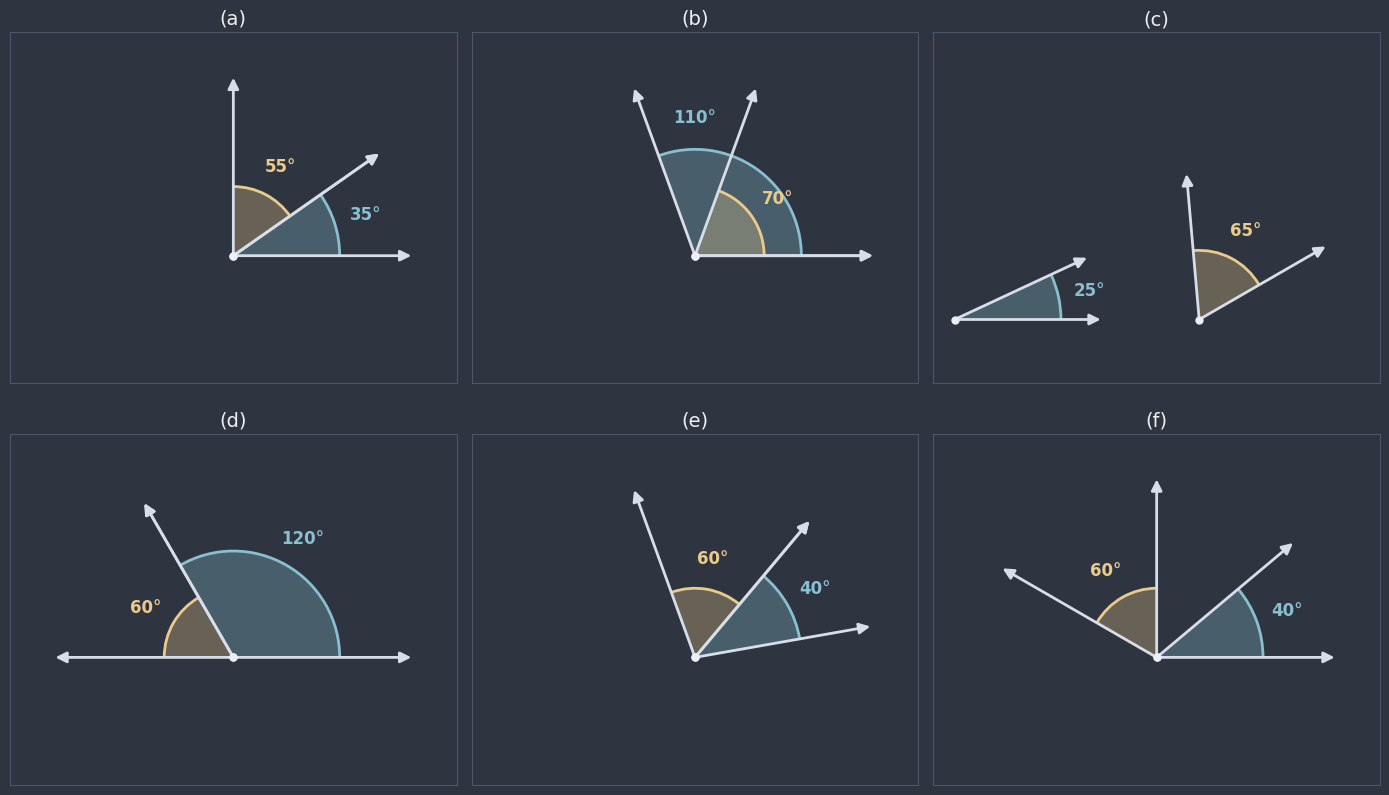

In [25]:
# Figura do Exercício Básico 2 (apenas desenha os pares; não precisa alterar)
# Cada ângulo é (vértice, direção do 1º lado, direção do 2º lado), como na seção 4
pares_ex2 = {
    "a": [((0, 0), 0, 35), ((0, 0), 35, 90)],
    "b": [((0, 0), 0, 110), ((0, 0), 0, 70)],
    "c": [((-1.9, -0.6), 0, 25), ((0.4, -0.6), 30, 95)],
    "d": [((0, 0), 0, 120), ((0, 0), 120, 180)],
    "e": [((0, 0), 10, 50), ((0, 0), 50, 110)],
    "f": [((0, 0), 0, 40), ((0, 0), 90, 150)],
}

fig, eixos = plt.subplots(2, 3, figsize=(14, 8.4))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, (letra, par) in zip(eixos.flat, pares_ex2.items()):
    preparar_eixo(ax, 2.1)
    ax.set_ylim(-1.2, 2.1)
    desenhar_par_de_angulos(ax, par)
    ax.set_title(f"({letra})", color=NORD_TEXTO, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Exercício Básico 2: para cada par de ângulos (a) a (f) da figura acima,
# responda com uma tupla (consecutivos, adjacentes, complementares, suplementares),
# usando True ou False em cada posição.
# Dica: some as medidas escritas no desenho; no par (b), repare que os dois
# ângulos começam no MESMO lado.
classificacao_ex2 = {
    "a": ...,
    "b": ...,
    "c": ...,
    "d": ...,
    "e": ...,
    "f": ...,
}

print(classificacao_ex2)

In [ ]:
# Verificação
gabarito_ex2 = {
    "a": (True, True, True, False),
    "b": (True, False, False, True),
    "c": (False, False, True, False),
    "d": (True, True, False, True),
    "e": (True, True, False, False),
    "f": (False, False, False, False),
}
dicas_ex2 = {
    "a": "os dois ângulos dividem o lado de 35° e juntos formam um ângulo reto",
    "b": "o ângulo de 70° está DENTRO do de 110°; e quanto dá 110 + 70?",
    "c": "vértices diferentes nunca são consecutivos, mas a soma das medidas ainda conta",
    "d": "os dois ângulos juntos formam um ângulo raso",
    "e": "são lado a lado, mas 40 + 60 não dá nem 90 nem 180",
    "f": "mesmo vértice, mas nenhum lado em comum",
}
for letra, certa in gabarito_ex2.items():
    resposta = classificacao_ex2[letra]
    assert resposta is not ... and tuple(resposta) == certa, (
        f"Tente de novo, revise: no par ({letra}), {dicas_ex2[letra]} "
        "(seção 4 - Ângulos consecutivos, adjacentes, complementares e suplementares)."
    )
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: complete as funções abaixo.
# - `complemento_ex3(medida)` devolve o complemento (um número) ou, se ele não
#   existir, uma mensagem de texto, como "não existe complemento".
# - `suplemento_ex3(medida)` faz o mesmo para o suplemento.
# Lembre: só existe complemento para 0° < medida < 90° e só existe suplemento
# para 0° < medida < 180°.


def complemento_ex3(medida: float) -> float | str:
    ...


def suplemento_ex3(medida: float) -> float | str:
    ...


print(complemento_ex3(30), complemento_ex3(120))
print(suplemento_ex3(30), suplemento_ex3(200))

In [ ]:
# Verificação
for medida, certo in {30: 60, 89.5: 0.5, 1: 89, 45: 45}.items():
    resposta = complemento_ex3(medida)
    assert isinstance(resposta, (int, float)) and math.isclose(resposta, certo), (
        f"Tente de novo, revise: o complemento de {medida:g}° é 90° - {medida:g}° "
        "(seção 4 - Ângulos consecutivos, adjacentes, complementares e suplementares)."
    )
for medida in (90, 120, 180, 300):
    assert isinstance(complemento_ex3(medida), str), (
        f"Tente de novo, revise: {medida}° não tem complemento, então a função deve devolver "
        "uma mensagem de texto (seção 4 - Ângulos consecutivos, adjacentes, complementares e suplementares)."
    )
for medida, certo in {120: 60, 179: 1, 30: 150, 90: 90}.items():
    resposta = suplemento_ex3(medida)
    assert isinstance(resposta, (int, float)) and math.isclose(resposta, certo), (
        f"Tente de novo, revise: o suplemento de {medida:g}° é 180° - {medida:g}° "
        "(seção 4 - Ângulos consecutivos, adjacentes, complementares e suplementares)."
    )
for medida in (180, 200, 270):
    assert isinstance(suplemento_ex3(medida), str), (
        f"Tente de novo, revise: {medida}° não tem suplemento, então a função deve devolver "
        "uma mensagem de texto (seção 4 - Ângulos consecutivos, adjacentes, complementares e suplementares)."
    )
print("Certo!")

In [ ]:
# Exercício Intermediário 4:
# (a) Duas retas concorrentes formam quatro ângulos em volta do vértice. Um
#     deles mede 63°. Andando em volta do vértice a partir dele, escreva as
#     medidas dos OUTROS TRÊS, na ordem: o vizinho, o oposto pelo vértice e o
#     outro vizinho. Guarde na tupla `angulos_ex4a`.
# (b) Complete a função `quatro_angulos_ex4`, que recebe a medida alfa de um dos
#     ângulos (0 < alfa < 180) e devolve a tupla com os QUATRO ângulos, começando
#     por alfa e seguindo em volta do vértice.
angulos_ex4a = (..., ..., ...)


def quatro_angulos_ex4(alfa: float) -> tuple[float, float, float, float]:
    ...


print(angulos_ex4a, quatro_angulos_ex4(40))

In [ ]:
# Verificação
assert angulos_ex4a is not ... and len(angulos_ex4a) == 3 and all(
    isinstance(a, (int, float)) and math.isclose(a, c) for a, c in zip(angulos_ex4a, (117, 63, 117))
), (
    "Tente de novo, revise: os vizinhos são suplementares do ângulo de 63° e o oposto pelo "
    "vértice é congruente a ele (seção 5 - Ângulos opostos pelo vértice e bissetriz)."
)
for alfa in (63, 40, 90, 12.5, 150):
    resposta = quatro_angulos_ex4(alfa)
    certo = (alfa, 180 - alfa, alfa, 180 - alfa)
    assert resposta is not None and len(resposta) == 4 and all(
        math.isclose(r, c) for r, c in zip(resposta, certo)
    ), (
        f"Tente de novo, revise: para alfa = {alfa:g}°, os quatro ângulos deveriam ser {certo}; "
        "vizinhos são suplementares e opostos são congruentes "
        "(seção 5 - Ângulos opostos pelo vértice e bissetriz)."
    )
    assert math.isclose(sum(resposta), 360), (
        "Tente de novo, revise: os quatro ângulos em volta do vértice somam 360° "
        "(seção 5 - Ângulos opostos pelo vértice e bissetriz)."
    )
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: um ângulo tem os lados nas direções dir_a e dir_b
# (em graus, com dir_a < dir_b e dir_b - dir_a <= 180), como na seção 5.
# (a) Complete `direcao_bissetriz_ex5`, que devolve a direção da bissetriz.
# (b) Complete `angulos_formados_ex5`, que devolve uma tupla com as medidas dos
#     DOIS ângulos formados pela bissetriz: (entre dir_a e a bissetriz,
#     entre a bissetriz e dir_b). Use a função do item (a).
# (c) A bissetriz divide um ângulo de 47° 30′ em duas partes. Quanto mede cada
#     parte, em graus, minutos e segundos? Responda com a tupla
#     `metade_ex5_gms = (graus, minutos, segundos)`, só com números inteiros.


def direcao_bissetriz_ex5(dir_a: float, dir_b: float) -> float:
    ...


def angulos_formados_ex5(dir_a: float, dir_b: float) -> tuple[float, float]:
    ...


metade_ex5_gms = (..., ..., ...)

print(direcao_bissetriz_ex5(20, 110), angulos_formados_ex5(20, 110), metade_ex5_gms)

In [ ]:
# Verificação
for (dir_a, dir_b), certa in {(20, 110): 65, (0, 180): 90, (45, 60): 52.5, (100, 250): 175, (-30, 30): 0}.items():
    resposta = direcao_bissetriz_ex5(dir_a, dir_b)
    assert resposta is not None and math.isclose(resposta, certa, abs_tol=1e-9), (
        f"Tente de novo, revise: com lados em {dir_a}° e {dir_b}°, a bissetriz fica na "
        "direção média dos lados (seção 5 - Ângulos opostos pelo vértice e bissetriz)."
    )
for dir_a, dir_b in [(20, 110), (0, 180), (45, 60), (100, 250), (10, 11)]:
    resposta = angulos_formados_ex5(dir_a, dir_b)
    assert resposta is not None and len(resposta) == 2, (
        "Tente de novo, revise: a função deve devolver uma tupla com duas medidas "
        "(seção 5 - Ângulos opostos pelo vértice e bissetriz)."
    )
    primeiro, segundo = resposta
    assert math.isclose(primeiro, segundo) and math.isclose(primeiro + segundo, dir_b - dir_a), (
        f"Tente de novo, revise: com lados em {dir_a}° e {dir_b}°, as duas partes devem ser "
        "congruentes e somar o ângulo todo (seção 5 - Ângulos opostos pelo vértice e bissetriz)."
    )
assert metade_ex5_gms is not ... and tuple(metade_ex5_gms) == (23, 45, 0), (
    "Tente de novo, revise: divida 47° 30′ por 2; o grau que sobra de 47 vira 60′ "
    "(seção 2 - Medida e classificação de ângulos)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6:
# (a) Vários ângulos consecutivos em volta de um mesmo ponto completam uma volta.
#     Complete a função `angulo_faltante_ex6`, que recebe uma lista com as medidas
#     de todos os ângulos MENOS UM e devolve a medida do que falta.
# (b) Quatro ângulos consecutivos em volta de um ponto completam uma volta e
#     medem x, 2x, 3x e 4x. Encontre x (guarde em `x_ex6`) e a medida do maior
#     dos quatro ângulos (guarde em `maior_angulo_ex6`).


def angulo_faltante_ex6(conhecidos: list[float]) -> float:
    ...


x_ex6 = ...
maior_angulo_ex6 = ...

print(angulo_faltante_ex6([100, 80, 95]), x_ex6, maior_angulo_ex6)

In [ ]:
# Verificação
casos_ex6 = [([100, 80, 95], 85), ([90, 90, 90], 90), ([30, 45, 60, 75, 100], 50), ([120.5, 119.5], 120), ([359], 1)]
for conhecidos, certo in casos_ex6:
    resposta = angulo_faltante_ex6(conhecidos)
    assert resposta is not None and math.isclose(resposta, certo), (
        f"Tente de novo, revise: com {conhecidos}, falta {certo}°; ângulos que completam uma "
        "volta em torno de um ponto somam 360° (seção 5 - Ângulos opostos pelo vértice e bissetriz)."
    )
assert x_ex6 is not ... and math.isclose(x_ex6, 36), (
    "Tente de novo, revise: x + 2x + 3x + 4x = 360°, então 10x = 360° "
    "(seção 5 - Ângulos opostos pelo vértice e bissetriz)."
)
assert maior_angulo_ex6 is not ... and math.isclose(maior_angulo_ex6, 144), (
    "Tente de novo, revise: o maior dos quatro ângulos é 4x "
    "(seção 5 - Ângulos opostos pelo vértice e bissetriz)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0401a_nocoes_e_proposicoes_primitivas.ipynb`](0401a_nocoes_e_proposicoes_primitivas.ipynb) (ponto, reta, plano e notação geométrica)
- [`0402a_segmento_de_reta.ipynb`](0402a_segmento_de_reta.ipynb) (semirreta e semirretas opostas, base da definição de ângulo; congruência e ponto médio, que inspiram a congruência de ângulos e a bissetriz)
- [`0104a_relacoes.ipynb`](../01_conjuntos_e_funcoes/0104a_relacoes.ipynb) (propriedades reflexiva, simétrica e transitiva, herdadas pela congruência de ângulos)

**Isso será usado em:**
- 📌 Triângulos (soma dos ângulos internos e ângulo externo)
- 📌 Paralelismo (ângulos formados por uma transversal, retomando opostos pelo vértice e suplementares)
- 📌 Perpendicularidade (ângulo reto como caso particular; bissetrizes de ângulos o.p.v. são perpendiculares)
- [`0501a_arcos_e_angulos.ipynb`](../05_trigonometria/0501a_arcos_e_angulos.ipynb) (o radiano, outra unidade de medida de ângulos, e o ciclo trigonométrico)
- [`0504a_reducao_ao_1o_quadrante.ipynb`](../05_trigonometria/0504a_reducao_ao_1o_quadrante.ipynb) (relação de co-função: seno e cosseno de ângulos complementares)